# Sample Graphics for Story 2 — Cultural Workforce and Opportunities for Suburban Expansion

| | |
|---|---|
| **Purpose** | Presentation-ready Matplotlib mockups for Story 2, built from the analysis in `explore_story2_arts_workers.ipynb` and `explore_census_activity_data.ipynb`. Figures are sized to paste directly into a Google Doc (7.5 in wide). |
| **Inputs** | `data/census/wards/toronto-wards.csv`, `toronto-wards-noc-naics.csv`, the broader inventory `current_toronto_arts_locations_eddit.csv`, `data/activity/wards/ward_to_*.csv`, `data/activity/venues_homes.csv`, `src/data/geo/city-wards.geo.json`, `src/data/venues/venues-centroids.geo.json` |
| **Outputs** | Inline figures and tables only. Nothing is written to disk. |
| **Kernel** | `py312` |

## Definition and narrative

**The headline cultural-workforce measure is `labour_cultural_workers`**, the broader occupation-based (NOC) measure. It includes creative occupations and related technical, instructional and administrative cultural roles. **Workers are assigned by home ward**, not by workplace.

Toronto’s workforce and infrastructure generally cluster together, so this is **not a blanket claim that suburban Toronto lacks arts infrastructure.** The story identifies a small number of wards where the workforce, the activity patterns and the infrastructure measures together suggest opportunities for expansion.

**Reading order:** (1) citywide workforce geography → (2) regional workforce versus high-frequency funding → (3) workforce versus infrastructure → (4) how the opportunity wards were selected → (5) three ward profiles with three different pathways for expansion.

## Caveats that apply to every figure

- **Normalized activity is not attendance**, a unique-person count or a percentage of residents participating, and the activity data describes **all residents** of a ward, not cultural workers specifically.
- The activity analysis covers **105 selected venues**. The broader inventory holds roughly **2,576 locations** with no comparable activity measurements, and counts presence, not size, quality or funding dollars.
- **Straight-line distance** is not route distance, travel time or difficulty.
- Cultural workers are counted by **home ward, not workplace**.
- Ward-level relationships are **ecological**: they describe wards, not individual behaviour, and do not establish causality.

## Visual language (shared with the Story 1 notebook)

Okabe–Ito colourblind-safe palette. **Region colours:** Toronto and East York = blue, Etobicoke York = orange, North York = green, Scarborough = purple. **Case-study wards** sit on a pale gold band with bold labels (Don Valley North, Willowdale and Eglinton-Lawrence strongly; Don Valley West as a lighter secondary case). Single-hue slate ramps show magnitude; indigo and grey markers distinguish workforce from infrastructure rankings. All settings live in the configuration cell.

In [1]:
import json
import textwrap
import warnings
from itertools import product
from pathlib import Path

import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash as pgh
import seaborn as sns
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr
from tqdm.auto import tqdm

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# ============================================================================
# CONFIGURATION: paths, definitions, colours, highlighted wards, plot parameters
# ============================================================================

# ---- paths (repo root = first ancestor holding sibling data/ and analysis/) ------
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir() and (p / "analysis").is_dir())
DATA = REPO_ROOT / "data"
SRC_DATA = REPO_ROOT / "src" / "data"

WARD_CENSUS_CSV = DATA / "census" / "wards" / "toronto-wards.csv"
WARD_NOC_NAICS_CSV = DATA / "census" / "wards" / "toronto-wards-noc-naics.csv"
WARD_GEOJSON = SRC_DATA / "geo" / "city-wards.geo.json"
VENUES_HOMES_CSV = DATA / "activity" / "venues_homes.csv"
VENUE_METRICS_JSON = SRC_DATA / "activity" / "venue_metrics.json"
VENUE_CENTROIDS_GEOJSON = SRC_DATA / "venues" / "venues-centroids.geo.json"
BROADER_INVENTORY_CSV = DATA / "venues" / "tac-list" / "current_toronto_arts_locations_eddit.csv"

WARDS_ACTIVITY_DIR = DATA / "activity" / "wards"
WARD_TO_VENUE_ACTIVITY_CSV = WARDS_ACTIVITY_DIR / "ward_to_venue_activity.csv"
WARD_TO_VENUE_SUMMARY_CSV = WARDS_ACTIVITY_DIR / "ward_to_venue_summary.csv"
WARD_TO_WARD_ACTIVITY_CSV = WARDS_ACTIVITY_DIR / "ward_to_ward_activity.csv"
WARD_TO_WARD_SUMMARY_CSV = WARDS_ACTIVITY_DIR / "ward_to_ward_summary.csv"

# ---- analysis parameters (same definitions as explore_story2_arts_workers.ipynb) ----
TIME_PERIOD = "all"
VALUE_COL = "normalized_raw_stop_count_by_ward"
MERIDIAN_VENUE_NAMES = ["Meridian Arts Centre"]

WARD_REGION = {
    "Etobicoke North": "Etobicoke York", "Etobicoke Centre": "Etobicoke York",
    "Etobicoke-Lakeshore": "Etobicoke York", "York South-Weston": "Etobicoke York",
    "York Centre": "Etobicoke York", "Humber River-Black Creek": "Etobicoke York",
    "Eglinton-Lawrence": "Etobicoke York",
    "Parkdale-High Park": "Toronto and East York", "Davenport": "Toronto and East York",
    "Spadina-Fort York": "Toronto and East York", "University-Rosedale": "Toronto and East York",
    "Toronto-St. Paul's": "Toronto and East York", "Toronto Centre": "Toronto and East York",
    "Toronto-Danforth": "Toronto and East York", "Beaches-East York": "Toronto and East York",
    "Don Valley West": "North York", "Don Valley East": "North York",
    "Don Valley North": "North York", "Willowdale": "North York",
    "Scarborough Southwest": "Scarborough", "Scarborough Centre": "Scarborough",
    "Scarborough-Agincourt": "Scarborough", "Scarborough North": "Scarborough",
    "Scarborough-Guildwood": "Scarborough", "Scarborough-Rouge Park": "Scarborough",
}
REGION_ORDER = ["Toronto and East York", "Etobicoke York", "North York", "Scarborough"]
SUBURBAN_REGIONS = REGION_ORDER[1:]
DOWNTOWN_CORE_WARDS = [w for w, r in WARD_REGION.items() if r == "Toronto and East York"]

# ---- cultural-workforce measures (never summed: they slice different, overlapping axes) ----
NOC_NAICS_MEASURES = ["labour_creatives", "labour_cultural_workers", "labour_cultural_industries",
                      "labour_independent_artists", "labour_arts_major"]
HEADLINE_MEASURE = "labour_cultural_workers"        # broader NOC occupation-based measure
ARTIST_MEASURE = "labour_creatives"                 # creative occupations
ARTIST_MEASURE_ALT = "labour_independent_artists"   # independent artists (industry-based)
WORKFORCE_SHORT = {"labour_creatives": "Creative\noccupations", "labour_cultural_workers": "Broader cultural\nworkers",
                   "labour_independent_artists": "Independent\nartists"}
INFRA_SHORT = {"n_locations": "Total\nlocations", "locations_per_100k": "Per 100k\nresidents",
               "n_tac_funded": "TAC-\nfunded", "n_activity_sample_venues": "Activity\nsample"}
# the 12 transparent comparisons: 3 workforce measures x 4 infrastructure measures
WORKFORCE_COLS_FOR_QUADRANT = [f"{ARTIST_MEASURE}_count", f"{HEADLINE_MEASURE}_count", f"{ARTIST_MEASURE_ALT}_count"]
INFRA_COLS_FOR_QUADRANT = ["n_locations", "locations_per_100k", "n_tac_funded", "n_activity_sample_venues"]
QUADRANT_SHARE_THRESHOLD = 0.5      # flagged by the quadrant method if flagged in >= half of the 12 comparisons
RANK_GAP_QUANTILE = 0.75            # rank-gap method: top quartile of (infrastructure rank - workforce rank)
RESIDUAL_QUANTILE = 0.25            # residual method: bottom quartile of the log-trend residual
FUNDING_FREQ_HIGH = ["high", "very_high"]
FREE_PROG_MEANINGFUL = ["mid", "high", "very_high"]

# ---- case-study and highlighted wards -------------------------------------------
MAIN_CASE_WARDS = ["Don Valley North", "Willowdale", "Eglinton-Lawrence"]
SECONDARY_WARDS = ["Don Valley West"]
HIGHLIGHT_WARDS = MAIN_CASE_WARDS + SECONDARY_WARDS
CASE_TYPE_LABELS = {
    "Don Valley North": "Clearest numerical shortfall,\nwith a nearby suburban\nnetwork already in place",
    "Willowdale": "An anchor institution at work,\nwith room for a broader\necosystem",
    "Eglinton-Lawrence": "A sizeable inventory that may\nneed more sustained\nprogramming",
}
CASE_NOTES = {
    "Don Valley North": "Residents already look beyond the ward: {outside_share:.0%} of their recorded activity is outside it, led by "
                        "{leading_dest} ({leading_dest_share:.0%}), a short trip away.",
    "Willowdale": "Meridian Arts Centre is one of only two included venues here and anchors local activity. One home area beside it supplies "
                  "{top_cell_share:.0%} of residents' recorded activity, so read the {within_share:.1%} within-ward share with care.",
    "Eglinton-Lawrence": "A larger inventory than the other two, yet {outside_share:.0%} of residents' recorded activity is outside the ward, "
                         "led by {leading_dest} ({leading_dest_share:.0%}).",
}
SCATTER_LABELLED = ["Don Valley North", "Willowdale", "Eglinton-Lawrence", "Don Valley West"]
# manual label offsets (points) for the scatter: ward -> (dx, dy, alignment)
SCATTER_LABEL_OFFSETS = {"Don Valley North": (-18, 20, "right"), "Willowdale": (-26, 22, "right"),
                         "Eglinton-Lawrence": (34, -30, "left"), "Don Valley West": (36, 24, "left")}
MATRIX_CANDIDATE_MIN_FLAGS = 5      # rows shown in the selection matrix: main + secondary wards, plus others flagged this often

# ---- colour language (Okabe-Ito based, colourblind-safe; shared with the Story 1 notebook) ----
INK, MUTED, GRID_COLOR, SURFACE = "#1F2933", "#5F6B76", "#E3E7EB", "#FFFFFF"
REGION_COLORS = {
    "Toronto and East York": "#0072B2",   # blue
    "Etobicoke York": "#E69F00",          # orange
    "North York": "#009E73",              # bluish green
    "Scarborough": "#CC79A7",             # reddish purple
}
WITHIN_COLOR = "#B4BCC4"
OUTSIDE_COLOR = "#D55E00"
HIGHLIGHT_BAND = "#FFF1B8"              # main case-study wards
HIGHLIGHT_BAND_SECONDARY = "#FFF8DC"    # secondary case (Don Valley West)
LINK_COLOR = "#C5CCD3"
WORKFORCE_COLOR = "#3B2F8F"             # workforce rank markers (indigo)
INFRA_COLOR = "#7A8793"                 # infrastructure rank markers (slate)
TREND_COLOR = "#1F2933"
SEQ_CMAP = LinearSegmentedColormap.from_list("slate_seq", ["#EEF1F4", "#9FB0C0", "#2F3E50"])   # single-hue magnitude ramp
FLAG_COLOR = "#2F3E50"
GOLD_OUTLINE = "#C99A00"                # outline of the main case-study wards on the map
HALO = [pe.withStroke(linewidth=2.6, foreground=SURFACE)]      # white outline so labels stay legible over lines and fills

# ---- profile-card rows: (profile key, label, value format ("ordinal" or a str.format spec), ward_view scale column, reversed scale?) ----
CARD_SECTIONS = [
    ("CULTURAL WORKFORCE", [("workers", "Cultural workers (home ward)", "{:,.0f}", f"{HEADLINE_MEASURE}_count", False)]),
    ("INFRASTRUCTURE (BROADER INVENTORY)", [
        ("locations", "Locations", "{:,.0f}", "n_locations", False),
        ("per_100k", "Locations per 100k residents", "{:,.0f}", "locations_per_100k", False),
        ("tac_funded", "TAC-funded locations", "{:,.0f}", "n_tac_funded", False),
        ("high_freq", "High-frequency funded locations", "{:,.0f}", "n_high_funding_freq", False),
    ]),
    ("RANK AMONG 25 WARDS (1 = HIGHEST, RIGHT)", [
        ("workforce_rank", "Average workforce rank", "ordinal", "avg_workforce_rank", True),
        ("infra_rank", "Average infrastructure rank", "ordinal", "avg_infra_rank", True),
    ]),
    ("RESIDENTS' ACTIVITY (ALL RESIDENTS)", [
        ("outside_share", "Activity outside the home ward", "{:.0%}", "outside_share", False),
        ("median_km", "Median straight-line distance", "{:.1f} km", "median_km", False),
    ]),
]
# ---- indicator-matrix columns: (group, [(header, unit, profile key, ward_view shading column, value format)]) ----
MATRIX_GROUPS = [
    ("Workforce", [("Cultural\nworkers", "residents", "workers", f"{HEADLINE_MEASURE}_count", "{:,.0f}")]),
    ("Infrastructure (broader inventory)", [("Locations", "count", "locations", "n_locations", "{:,.0f}"),
                                           ("Per 100k", "residents", "per_100k", "locations_per_100k", "{:,.0f}"),
                                           ("TAC-\nfunded", "count", "tac_funded", "n_tac_funded", "{:,.0f}"),
                                           ("High-\nfrequency", "count", "high_freq", "n_high_funding_freq", "{:,.0f}")]),
    ("Rank (1 = highest)", [("Workforce", "avg. rank", "workforce_rank", "avg_workforce_rank", "ordinal"),
                           ("Infra-\nstructure", "avg. rank", "infra_rank", "avg_infra_rank", "ordinal")]),
    ("Residents' activity", [("Outside\nward", "% of activity", "outside_share", "outside_share", "{:.0%}"),
                            ("Median\ndistance", "km", "median_km", "median_km", "{:.1f}")]),
]

# ---- figure format (copy-paste ready for a Google Doc: ~6.5-7.5 in wide) -------
FIG_W = 7.5
FIG_DPI = 150
TITLE_SIZE, SUBTITLE_SIZE, LABEL_SIZE, TICK_SIZE, NOTE_SIZE = 12.5, 8.8, 9, 8.3, 7
RC_PARAMS = {
    "figure.dpi": FIG_DPI, "savefig.dpi": FIG_DPI, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "axes.labelsize": LABEL_SIZE, "xtick.labelsize": TICK_SIZE, "ytick.labelsize": TICK_SIZE,
    "xtick.color": MUTED, "ytick.color": INK, "text.color": INK, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "legend.fontsize": 8, "axes.grid": False,
}
plt.rcParams.update(RC_PARAMS)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ---- expected values from the brief, used ONLY as validation targets: name -> (value, tolerance) ----
EXPECTED = {
    "Toronto and East York share of population": (0.325, 0.0006),
    "Toronto and East York share of broader cultural workforce": (0.644, 0.0006),
    "Toronto and East York workforce share, lowest of five measures": (0.554, 0.0006),
    "Toronto and East York workforce share, highest of five measures": (0.744, 0.0006),
    "Etobicoke York: workforce share": (0.160, 0.0006), "Etobicoke York: high-frequency location share": (0.134, 0.0006),
    "North York: workforce share": (0.104, 0.0006), "North York: high-frequency location share": (0.063, 0.0006),
    "Scarborough: workforce share": (0.091, 0.0006), "Scarborough: high-frequency location share": (0.079, 0.0006),
    "Toronto and East York: workforce share": (0.644, 0.0006), "Toronto and East York: high-frequency location share": (0.723, 0.0006),
    "Spearman rho, cultural workers vs total locations": (0.73, 0.005),
    "Willowdale: comparisons flagging (of 12)": (12, 0), "Willowdale: broader methods flagging (of 3)": (3, 0),
    "Don Valley North: comparisons flagging (of 12)": (8, 0), "Don Valley North: broader methods flagging (of 3)": (3, 0),
    "Eglinton-Lawrence: comparisons flagging (of 12)": (12, 0), "Eglinton-Lawrence: broader methods flagging (of 3)": (2, 0),
    "Don Valley West: comparisons flagging (of 12)": (9, 0), "Don Valley West: broader methods flagging (of 3)": (2, 0),
    "Don Valley North: cultural workers": (1892, 0.5), "Don Valley North: locations": (42, 0), "Don Valley North: locations per 100k": (37, 0.5),
    "Don Valley North: TAC-funded locations": (33, 0), "Don Valley North: high-frequency funded locations": (3, 0),
    "Don Valley North: average workforce rank": (15, 0.5), "Don Valley North: average infrastructure rank": (21, 0.5),
    "Don Valley North: residents' activity outside ward": (0.63, 0.005), "Don Valley North: median distance (km)": (4.6, 0.05),
    "Willowdale: cultural workers": (2234, 0.5), "Willowdale: locations": (54, 0), "Willowdale: locations per 100k": (46, 0.5),
    "Willowdale: TAC-funded locations": (50, 0), "Willowdale: high-frequency funded locations": (7, 0),
    "Willowdale: average workforce rank": (12, 0.5), "Willowdale: average infrastructure rank": (17, 0.5),
    "Willowdale: residents' activity within ward": (0.945, 0.0006),
    "Eglinton-Lawrence: cultural workers": (2374, 0.5), "Eglinton-Lawrence: locations": (70, 0), "Eglinton-Lawrence: locations per 100k": (60, 0.5),
    "Eglinton-Lawrence: TAC-funded locations": (58, 0), "Eglinton-Lawrence: high-frequency funded locations": (5, 0),
    "Eglinton-Lawrence: average workforce rank": (11, 0.5), "Eglinton-Lawrence: average infrastructure rank": (15, 0.5),
    "Eglinton-Lawrence: residents' activity outside ward": (0.74, 0.005), "Eglinton-Lawrence: median distance (km)": (5.4, 0.05),
}

In [3]:
# ============================================================================
# HELPERS
# ============================================================================

# ---- analysis helpers ------------------------------------------------------------
def region_of(ward):
    return "Downtown/core" if ward in DOWNTOWN_CORE_WARDS else WARD_REGION[ward]


def weighted_quantiles(df, value_col, weight_col, qs=(0.25, 0.5, 0.75)):
    d = df.sort_values(value_col)
    cum_w = d[weight_col].cumsum() / d[weight_col].sum()
    return {q: float(np.interp(q, cum_w, d[value_col])) for q in qs}


def ordinal(n):
    n = int(np.floor(n + 0.5))      # round half up (16.5 -> 17th)
    suffix = "th" if 10 <= n % 100 <= 20 else {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


def format_value(spec, v):
    return ordinal(v) if spec == "ordinal" else spec.format(v)


def build_home_distances():
    """Straight-line distance (km) from each home geohash6 centre to each venue, tagged with origin/dest ward.

    Mirrors explore_story2_arts_workers.ipynb Section 7 (UTM-projected, ward via point-in-polygon).
    """
    homes = pd.read_csv(VENUES_HOMES_CSV)
    homes = homes[homes["time_period"] == TIME_PERIOD].copy()
    cells = pd.DataFrame({"home_geohash6": homes["home_geohash6"].unique()})
    decoded = [pgh.decode(g) for g in tqdm(cells["home_geohash6"], desc="decoding home geohash6 cells")]
    cells["home_lat"], cells["home_lon"] = [d[0] for d in decoded], [d[1] for d in decoded]
    cell_pts = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(cells["home_lon"], cells["home_lat"]), crs="EPSG:4326")
    cell_ward = gpd.sjoin(cell_pts, wards_gdf[["ward_name", "geometry"]], predicate="within")[["home_geohash6", "ward_name"]]
    cell_ward = cell_ward.rename(columns={"ward_name": "origin_ward"})
    cell_xy = cell_pts.to_crs(UTM_CRS)
    cells["easting"], cells["northing"] = cell_xy.geometry.x.values, cell_xy.geometry.y.values
    venue_xy = venue_points.to_crs(UTM_CRS)
    venue_coords = pd.DataFrame({"venue_id": venue_points["venue_id"].values,
                                 "v_easting": venue_xy.geometry.x.values, "v_northing": venue_xy.geometry.y.values})
    out = (homes.merge(cells[["home_geohash6", "easting", "northing"]], on="home_geohash6")
                .merge(venue_coords, on="venue_id")
                .merge(cell_ward, on="home_geohash6", how="left")
                .merge(venue_to_dest_ward[["venue_id", "dest_ward"]], on="venue_id", how="left"))
    out["distance_km"] = np.hypot(out["easting"] - out["v_easting"], out["northing"] - out["v_northing"]) / 1000
    print(f"home cells with no ward match (excluded from distance summaries): {out['origin_ward'].isna().sum()} / {len(out)} rows")
    return out.dropna(subset=["origin_ward", "distance_km"])


def run_checks(rows):
    """rows: list of (name, computed). Compares against EXPECTED (value, tolerance); returns a tidy table."""
    out = []
    for name, value in rows:
        expected, tol = EXPECTED[name]
        out.append({"check": name, "computed": value, "expected": expected,
                    "status": "OK" if abs(value - expected) <= tol + 1e-9 else "CHECK"})
    table = pd.DataFrame(out)
    display(table.style.hide(axis="index").format({"computed": "{:,.3f}", "expected": "{:,.3f}"}))
    n_bad = (table["status"] != "OK").sum()
    print(f"{len(table) - n_bad}/{len(table)} validation checks within tolerance" + ("" if n_bad == 0 else "  <-- diagnose before trusting the figure"))
    return table


# ---- plotting helpers ---------------------------------------------------------------
def pct_fmt():
    return FuncFormatter(lambda v, _: f"{v:.0f}%")


def style_axes(ax, grid_axis="x"):
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID_COLOR)


def title_block(fig, title, subtitle=None, title_wrap=64, sub_wrap=98):
    """Left-aligned wrapped title + muted subtitle at the top of the figure.

    Returns the figure-fraction y of the block's bottom edge, so callers can set subplots_adjust(top=...).
    """
    H = fig.get_figheight()
    t = textwrap.fill(title, title_wrap)
    fig.text(0.015, 1 - 0.07 / H, t, fontsize=TITLE_SIZE, fontweight="bold", ha="left", va="top", linespacing=1.15)
    y = 1 - (0.07 + (t.count("\n") + 1) * TITLE_SIZE * 1.25 / 72 + 0.09) / H
    if subtitle:
        sub = textwrap.fill(subtitle, sub_wrap)
        fig.text(0.015, y, sub, fontsize=SUBTITLE_SIZE, color=MUTED, ha="left", va="top", linespacing=1.35)
        y -= ((sub.count("\n") + 1) * SUBTITLE_SIZE * 1.4 / 72 + 0.06) / H
    return y


def source_note(fig, text, wrap=130, y=0.008):
    fig.text(0.015, y, textwrap.fill(text, wrap), fontsize=NOTE_SIZE, color=MUTED, ha="left", va="bottom", linespacing=1.3)


def region_markers(ax, wards, x=-0.012, size=26):
    """Small coloured squares left of each y tick: the ward's Community Council region."""
    ys = np.arange(len(wards))
    ax.scatter([x] * len(wards), ys, s=size, marker="s", c=[REGION_COLORS[WARD_REGION[w]] for w in wards],
               transform=ax.get_yaxis_transform(), clip_on=False, zorder=5, linewidths=0)


def region_legend(fig, y=0.03, ncol=4, x=0.5):
    handles = [Line2D([0], [0], marker="s", linestyle="", markersize=7, color=REGION_COLORS[r], label=r) for r in REGION_ORDER]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(x, y), ncol=ncol, fontsize=8, handletextpad=0.3, columnspacing=1.2)


def highlight_rows(ax, wards, highlight=HIGHLIGHT_WARDS, x0=-0.40):
    """Pale band behind highlighted ward rows (extends under the tick labels) + bold labels."""
    for i, w in enumerate(wards):
        if w in highlight:
            ax.add_patch(Rectangle((x0, i - 0.5), 1 - x0, 1, transform=ax.get_yaxis_transform(), facecolor=HIGHLIGHT_BAND,
                                   edgecolor="none", clip_on=False, zorder=0))
    for lab in ax.get_yticklabels():
        if lab.get_text() in highlight:
            lab.set_fontweight("bold")

## Data loading and QA

Loading, joins and QA reuse the definitions from the reference notebooks: all census, workforce, geometry and activity files join on the same 25 ward names, the published workforce percentages reproduce from their counts, and the activity tables reconcile. The broader inventory is assigned to wards by point-in-polygon, and `compare` holds one row per ward with the workforce and infrastructure measures used throughout. Expected values from the brief appear only in the validation tables; every number on a figure is computed from the source data.

In [4]:
# --- cultural-workforce file (custom NOC / NAICS / CIP tabulations, by home ward) --------
ward_noc_naics = pd.read_csv(WARD_NOC_NAICS_CSV, dtype={"ward_code": str})
ward_noc_naics["ward_code"] = ward_noc_naics["ward_code"].str.zfill(2)
ward_noc_naics["region"] = ward_noc_naics["ward_name"].map(WARD_REGION)
assert ward_noc_naics.shape[0] == 25 and ward_noc_naics["region"].notna().all()

# --- general census (long form): all-ages population ------------------------------------
census_long = pd.read_csv(WARD_CENSUS_CSV, dtype={"ward_code": str}, encoding="latin1")
ward_pop = (census_long.loc[census_long["CHARACTERISTIC_CODE"] == "pop_2021", ["ward_code", "ward_name", "C1_COUNT_TOTAL"]]
            .rename(columns={"C1_COUNT_TOTAL": "population_2021_allages"}))
ward_pop["region"] = ward_pop["ward_name"].map(WARD_REGION)
assert len(ward_pop) == 25 and ward_pop["region"].notna().all()

# --- ward-level activity tables (same renames as the reference notebooks) ---------------
ward_to_venue_activity = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward", "home_ward": "is_home_ward"})
ward_to_ward_activity = pd.read_csv(WARD_TO_WARD_ACTIVITY_CSV).rename(columns={"ward_name": "origin_ward", "venue_ward": "dest_ward"})
ward_to_ward_summary = pd.read_csv(WARD_TO_WARD_SUMMARY_CSV).rename(columns={"ward_name": "origin_ward"})

# --- geometry, venue metadata, destination ward per venue -------------------------------
wards_gdf = gpd.read_file(WARD_GEOJSON)
wards_gdf = wards_gdf[wards_gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
if wards_gdf.crs is None:
    wards_gdf = wards_gdf.set_crs("EPSG:4326")
UTM_CRS = wards_gdf.estimate_utm_crs()

with open(VENUE_CENTROIDS_GEOJSON) as f:
    venue_meta = pd.json_normalize([ft["properties"] | {"lon": ft["geometry"]["coordinates"][0], "lat": ft["geometry"]["coordinates"][1]}
                                    for ft in json.load(f)["features"]])
venue_meta["venue_id"] = venue_meta["id"].astype(int)
venue_points = gpd.GeoDataFrame(venue_meta[["venue_id", "venue_name", "lat", "lon"]],
                                geometry=gpd.points_from_xy(venue_meta["lon"], venue_meta["lat"]), crs="EPSG:4326")
venue_to_dest_ward = (ward_to_venue_activity.loc[ward_to_venue_activity["is_home_ward"], ["venue_id", "venue_name", "dest_ward"]]
                      .drop_duplicates())
venues_per_ward = venue_to_dest_ward.groupby("dest_ward").size().rename("n_activity_sample_venues")

# --- condensed QA (same checks as the reference notebook) -------------------------------
assert set(ward_noc_naics["ward_name"]) == set(ward_pop["ward_name"]) == set(wards_gdf["ward_name"]) == set(ward_to_ward_summary["origin_ward"])
assert len(venue_meta) == 105 == venue_to_dest_ward["venue_id"].nunique()
assert ward_to_venue_activity.shape[0] == 105 * 25, "expected a dense venue x ward cross-join"
max_pct_diff = max((100 * ward_noc_naics[f"{m}_count"] / ward_noc_naics["pop_2021_count"] - ward_noc_naics[f"{m}_pct"]).abs().max()
                   for m in NOC_NAICS_MEASURES)
assert max_pct_diff < 0.1, "published pct fields do not reproduce from pop_2021_count"
by_flag = ward_to_ward_activity.groupby(["origin_ward", "same_ward"])[VALUE_COL].sum().unstack()
recon = ward_to_ward_summary.set_index("origin_ward")
assert (recon["normalized_raw_stop_count_within_ward"] - by_flag[True]).abs().max() < 1e-6
assert (recon["normalized_raw_stop_count_outside_ward"] - by_flag[False]).abs().max() < 1e-6
assert ward_noc_naics[[f"{m}_count" for m in NOC_NAICS_MEASURES]].notna().all().all()
age15_ratio = ward_noc_naics["pop_2021_count"].sum() / ward_pop["population_2021_allages"].sum()
print(f"25 wards | workforce pct fields reproduce from counts (max diff {max_pct_diff:.3f} pp) | "
      f"workforce universe (age 15+) is {age15_ratio:.1%} of the all-ages population")
print("QA passed: ward keys agree across census, workforce, geometry and activity files; activity tables reconcile.")

25 wards | workforce pct fields reproduce from counts (max diff 0.050 pp) | workforce universe (age 15+) is 84.5% of the all-ages population
QA passed: ward keys agree across census, workforce, geometry and activity files; activity tables reconcile.


In [5]:
# --- broader inventory (~2,576 locations) assigned to wards by point-in-polygon ------------
broader = pd.read_csv(BROADER_INVENTORY_CSV)
assert (broader["TAC_funded_activities"] == broader["funding_frequency"].notna()).all(), "funding metadata should exist exactly for TAC-funded rows"
broader_ward = gpd.sjoin(gpd.GeoDataFrame(broader, geometry=gpd.points_from_xy(broader["lon"], broader["lat"]), crs="EPSG:4326"),
                         wards_gdf[["ward_name", "geometry"]], predicate="within")
print(f"broader inventory: {len(broader):,} locations; {len(broader_ward):,} fall inside a ward polygon")

freq_high = broader_ward[broader_ward["funding_frequency"].isin(FUNDING_FREQ_HIGH)].groupby("ward_name").size().rename("n_high_funding_freq")
free_meaningful = broader_ward[broader_ward["free_programming"].isin(FREE_PROG_MEANINGFUL)].groupby("ward_name").size().rename("n_meaningful_free_programming")
ward_inventory = (broader_ward.groupby("ward_name").agg(n_locations=("lat", "size"), n_tac_funded=("TAC_funded_activities", "sum")).reset_index()
                  .merge(ward_pop[["ward_name", "population_2021_allages"]], on="ward_name")
                  .merge(ward_noc_naics[["ward_name"] + [f"{m}_count" for m in NOC_NAICS_MEASURES] + [f"{m}_pct" for m in NOC_NAICS_MEASURES]], on="ward_name")
                  .merge(venues_per_ward, left_on="ward_name", right_index=True, how="left")
                  .merge(freq_high, on="ward_name", how="left").merge(free_meaningful, on="ward_name", how="left"))
for col in ("n_activity_sample_venues", "n_high_funding_freq", "n_meaningful_free_programming"):
    ward_inventory[col] = ward_inventory[col].fillna(0).astype(int)
ward_inventory["n_tac_funded"] = ward_inventory["n_tac_funded"].astype(int)
ward_inventory["locations_per_100k"] = ward_inventory["n_locations"] / ward_inventory["population_2021_allages"] * 1e5
ward_inventory["meaningful_free_programming_share"] = ward_inventory["n_meaningful_free_programming"] / ward_inventory["n_locations"]
ward_inventory["region"] = ward_inventory["ward_name"].map(WARD_REGION)
assert len(ward_inventory) == 25
compare = ward_inventory.copy()      # one row per ward: workforce + infrastructure measures

broader inventory: 2,576 locations; 2,576 fall inside a ward polygon


## 1. Cultural-workforce counts by ward

**Claim to support:** Toronto’s cultural workforce lives across the whole city. Absolute counts are high in several suburban wards, even though *concentration* (workers as a share of residents) is highest downtown. These are two different measures and both appear below.

In [6]:
# --- regional shares: population, broader cultural workforce, high-frequency funded locations ---
region_table = pd.DataFrame({
    "population": ward_pop.groupby("region")["population_2021_allages"].sum(),
    "workforce": ward_noc_naics.groupby("region")[f"{HEADLINE_MEASURE}_count"].sum(),
    "high_frequency_locations": ward_inventory.groupby("region")["n_high_funding_freq"].sum(),
    "total_locations": ward_inventory.groupby("region")["n_locations"].sum(),
}).reindex(REGION_ORDER)
region_share = region_table / region_table.sum()
region_share["gap_pp"] = (region_share["workforce"] - region_share["high_frequency_locations"]) * 100     # percentage points
display((region_share[["population", "workforce", "high_frequency_locations", "total_locations"]] * 100).round(1).join(region_share["gap_pp"].round(1)))

# workforce share of Toronto and East York under each of the five measures (never summed across measures)
tey_share_by_measure = pd.Series({m: ward_noc_naics.loc[ward_noc_naics["region"] == "Toronto and East York", f"{m}_count"].sum()
                                     / ward_noc_naics[f"{m}_count"].sum() for m in NOC_NAICS_MEASURES})
print("Toronto and East York share of workforce, by measure:", tey_share_by_measure.round(3).to_dict())

checks_workforce_concentration = run_checks([
    ("Toronto and East York share of population", region_share.loc["Toronto and East York", "population"]),
    ("Toronto and East York share of broader cultural workforce", region_share.loc["Toronto and East York", "workforce"]),
    ("Toronto and East York workforce share, lowest of five measures", tey_share_by_measure.min()),
    ("Toronto and East York workforce share, highest of five measures", tey_share_by_measure.max())])

,population,workforce,high_frequency_locations,total_locations,gap_pp
region,,,,,
Toronto and East York,32.500,64.400,72.300,57.900,-7.900
Etobicoke York,29.700,16.000,13.400,19.900,2.600
North York,15.300,10.400,6.300,8.700,4.100
Scarborough,22.500,9.100,7.900,13.500,1.200


Toronto and East York share of workforce, by measure: {'labour_creatives': 0.659, 'labour_cultural_workers': 0.644, 'labour_cultural_industries': 0.637, 'labour_independent_artists': 0.744, 'labour_arts_major': 0.554}


check,computed,expected,status
Toronto and East York share of population,0.325,0.325,OK
Toronto and East York share of broader cultural workforce,0.644,0.644,OK
"Toronto and East York workforce share, lowest of five measures",0.554,0.554,OK
"Toronto and East York workforce share, highest of five measures",0.744,0.744,OK


4/4 validation checks within tolerance


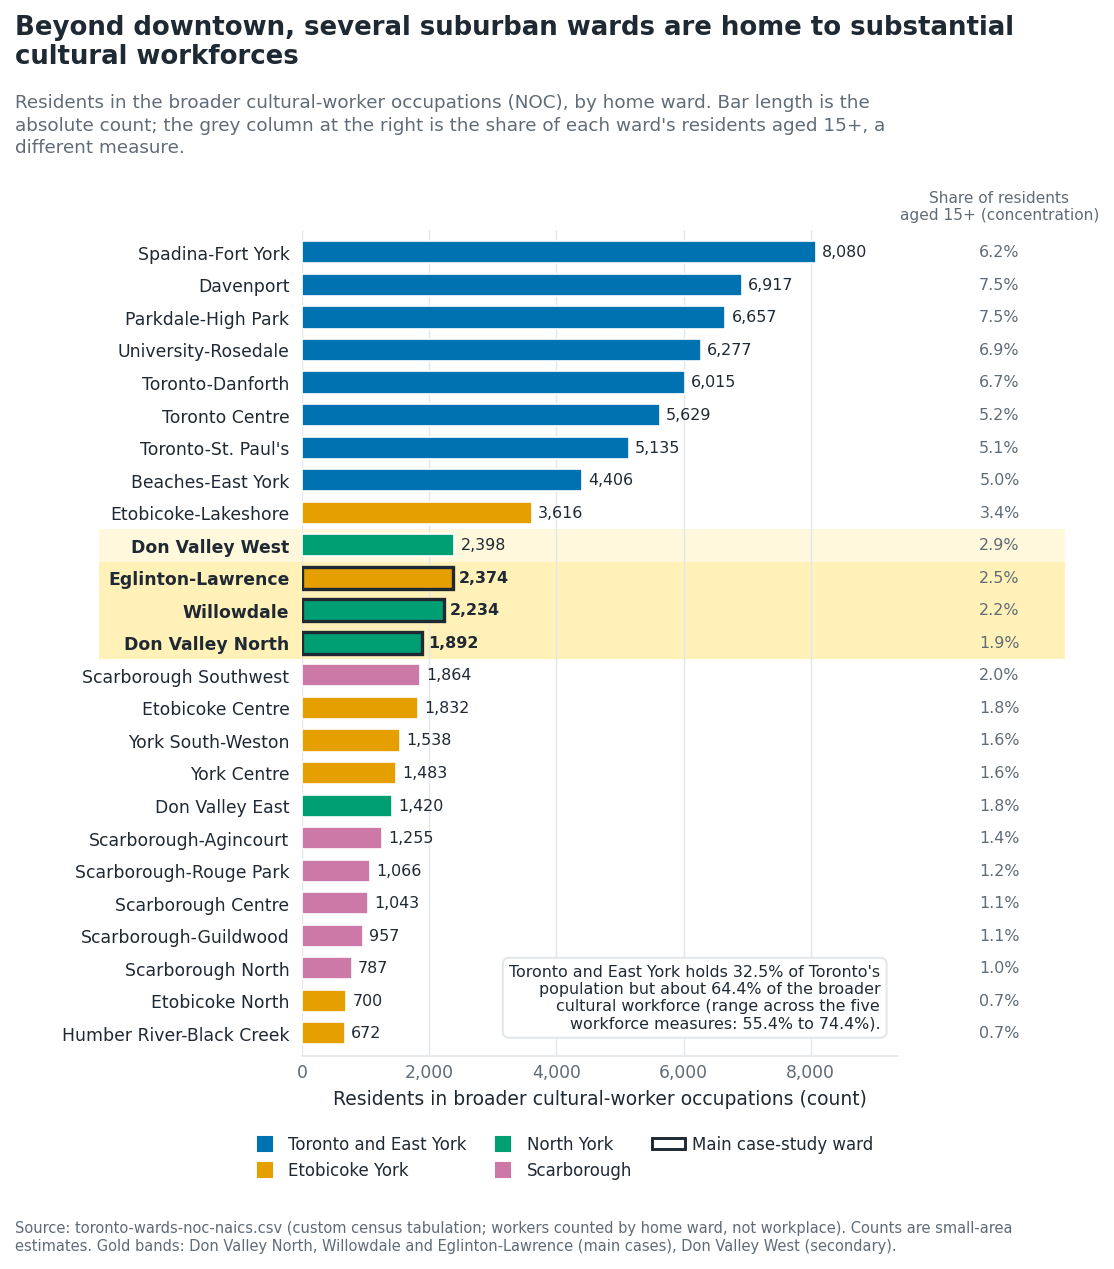

In [7]:
def plot_workforce_counts(df):
    col = f"{HEADLINE_MEASURE}_count"
    d = df.sort_values(col, ascending=True).reset_index(drop=True)
    wards, y = d["ward_name"].tolist(), np.arange(len(d))
    tey_pop, tey_workers = region_share.loc["Toronto and East York", "population"], region_share.loc["Toronto and East York", "workforce"]

    fig = plt.figure(figsize=(FIG_W, 8.4))
    top = title_block(fig, "Beyond downtown, several suburban wards are home to substantial cultural workforces",
                      "Residents in the broader cultural-worker occupations (NOC), by home ward. Bar length is the absolute count; the grey column at the "
                      "right is the share of each ward's residents aged 15+, a different measure.")
    fig.subplots_adjust(left=0.27, right=0.80, top=top - 0.04, bottom=0.165)
    ax = fig.add_subplot(111)
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.set_xlim(0, d[col].max() * 1.16)
    ax.set_yticks(y)
    ax.set_yticklabels(wards)
    for i, w in enumerate(wards):
        if w in HIGHLIGHT_WARDS:
            ax.add_patch(Rectangle((-0.34, i - 0.5), 1.62, 1, transform=ax.get_yaxis_transform(), facecolor=HIGHLIGHT_BAND if w in MAIN_CASE_WARDS else HIGHLIGHT_BAND_SECONDARY,
                                   edgecolor="none", clip_on=False, zorder=0))
    is_main, is_sec = d["ward_name"].isin(MAIN_CASE_WARDS).values, d["ward_name"].isin(SECONDARY_WARDS).values
    ax.barh(y, d[col], height=0.68, color=[REGION_COLORS[r] for r in d["region"]], edgecolor=np.where(is_main, INK, SURFACE),
            linewidth=np.where(is_main, 1.6, 0.8), zorder=2)
    for yi, v, m, s_ in zip(y, d[col], is_main, is_sec):
        ax.text(v + d[col].max() * 0.012, yi, f"{v:,.0f}", va="center", ha="left", fontsize=7.6, fontweight="bold" if m else "normal", zorder=3)
    for lab in ax.get_yticklabels():
        if lab.get_text() in MAIN_CASE_WARDS:
            lab.set_fontweight("bold")
        elif lab.get_text() in SECONDARY_WARDS:
            lab.set_fontweight("semibold")
    tr = ax.get_yaxis_transform()
    ax.text(1.17, len(d) - 0.1, "Share of residents\naged 15+ (concentration)", transform=tr, ha="center", va="bottom", fontsize=7.4, color=MUTED, linespacing=1.2)
    for yi, p in zip(y, d[f"{HEADLINE_MEASURE}_pct"]):
        ax.text(1.17, yi, f"{p:.1f}%", transform=tr, ha="center", va="center", fontsize=7.6, color=MUTED)
    ax.tick_params(axis="y", pad=6)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_xlabel("Residents in broader cultural-worker occupations (count)")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    ax.text(0.97, 0.03, f"Toronto and East York holds {tey_pop:.1%} of Toronto's\npopulation but about {tey_workers:.1%} of the broader\n"
                        f"cultural workforce (range across the five\nworkforce measures: {tey_share_by_measure.min():.1%} to {tey_share_by_measure.max():.1%}).",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7.6, bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=GRID_COLOR), zorder=5)
    handles = [Line2D([0], [0], marker="s", linestyle="", markersize=7, color=REGION_COLORS[r], label=r) for r in REGION_ORDER]
    handles.append(Patch(facecolor="none", edgecolor=INK, linewidth=1.4, label="Main case-study ward"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.055), ncol=3, fontsize=8, handletextpad=0.4, columnspacing=1.2)
    source_note(fig, "Source: toronto-wards-noc-naics.csv (custom census tabulation; workers counted by home ward, not workplace). Counts are small-area estimates. "
                     "Gold bands: Don Valley North, Willowdale and Eglinton-Lawrence (main cases), Don Valley West (secondary).", wrap=135)
    plt.show()


plot_workforce_counts(compare)

**What it shows.** Residents in the broader cultural-worker occupations in each of the 25 wards, sorted by count and coloured by region. The grey column at the right shows each ward’s concentration, the share of residents aged 15+. Don Valley North, Willowdale and Eglinton-Lawrence carry a gold band and outlined bars; Don Valley West is highlighted more lightly.

**Narrative claim.** Toronto and East York holds 32.5% of Toronto’s population but about 64.4% of the broader cultural workforce (55.4% to 74.4% across the five measures), and the eight downtown wards are the eight highest by count. Beyond them, five wards sit between about 1,900 and 3,600 workers (Etobicoke-Lakeshore, Don Valley West, Eglinton-Lawrence, Willowdale and Don Valley North), so suburban Toronto has substantial resident cultural workforces of its own.

**Count and concentration differ.** Don Valley North’s count (1,892) is exactly the median across the 25 wards, but those workers are 1.9% of its residents aged 15+, compared with 5.0% to 7.5% in the eight downtown wards. A ward can look mid-table on count and low on concentration.

**Limitations.**
- Counts are small-area estimates from a custom census tabulation and are not independent head-counts.
- The measure captures where workers *live*, not where they work or perform.
- Large populations produce large counts, so the count ordering partly reflects ward population (the 15+ population ranges across wards, as the reference notebook documents).

**Primary vs. alternative.** The **sorted bar is the strongest opening graphic**: exact counts, region colours and highlights are readable at a glance, and the concentration column makes the count-versus-share distinction explicit.

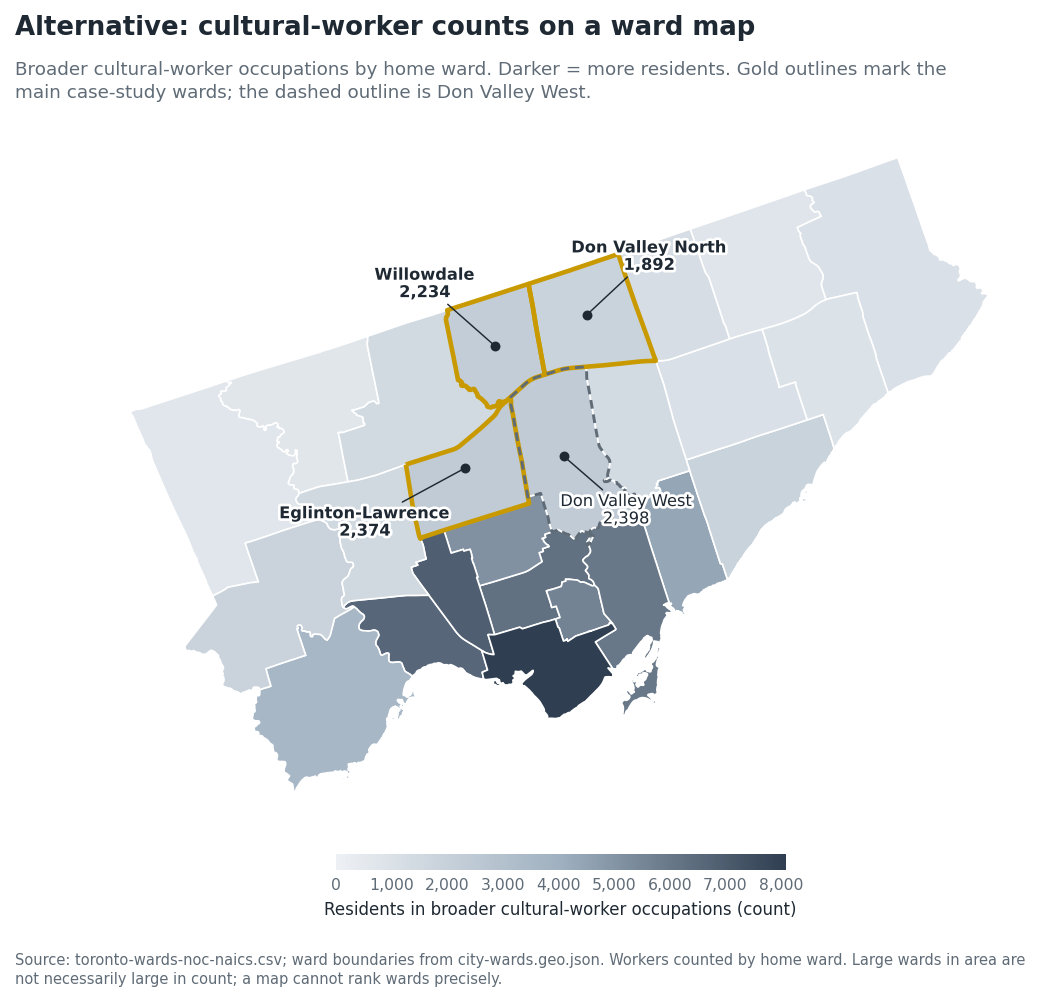

In [8]:
def plot_workforce_choropleth(df):
    col = f"{HEADLINE_MEASURE}_count"
    gdf = wards_gdf.merge(df[["ward_name", col]], on="ward_name").to_crs(UTM_CRS)
    fig = plt.figure(figsize=(FIG_W, 6.6))
    top = title_block(fig, "Alternative: cultural-worker counts on a ward map",
                      "Broader cultural-worker occupations by home ward. Darker = more residents. Gold outlines mark the main case-study wards; the dashed outline is Don Valley West.")
    fig.subplots_adjust(left=0.02, right=0.98, top=top - 0.005, bottom=0.17)
    ax = fig.add_subplot(111)
    norm = Normalize(vmin=0, vmax=gdf[col].max())
    gdf.plot(ax=ax, column=col, cmap=SEQ_CMAP, norm=norm, edgecolor="white", linewidth=0.8, zorder=1)
    for w in HIGHLIGHT_WARDS:
        gdf[gdf["ward_name"] == w].boundary.plot(ax=ax, color=GOLD_OUTLINE if w in MAIN_CASE_WARDS else MUTED, linewidth=2.2 if w in MAIN_CASE_WARDS else 1.4,
                                                 linestyle="-" if w in MAIN_CASE_WARDS else (0, (3, 2)), zorder=3)
    ax.set_axis_off()
    pts = gdf.set_index("ward_name").geometry.representative_point()
    label_offsets = {"Don Valley North": (30, 28), "Willowdale": (-34, 30), "Eglinton-Lawrence": (-48, -26), "Don Valley West": (30, -26)}
    for w in HIGHLIGHT_WARDS:
        v = gdf.loc[gdf["ward_name"] == w, col].iloc[0]
        ax.annotate(f"{w}\n{v:,.0f}", (pts[w].x, pts[w].y), xytext=label_offsets[w], textcoords="offset points", ha="center", va="center", fontsize=7.8,
                    fontweight="bold" if w in MAIN_CASE_WARDS else "normal", path_effects=HALO, zorder=6,
                    arrowprops=dict(arrowstyle="-", color=INK, linewidth=0.7, shrinkA=0, shrinkB=0))
        ax.scatter(pts[w].x, pts[w].y, s=14, color=INK, zorder=5)
    cax = fig.add_axes([0.30, 0.125, 0.40, 0.016])
    cb = fig.colorbar(ScalarMappable(norm=norm, cmap=SEQ_CMAP), cax=cax, orientation="horizontal")
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0, labelsize=7.5)
    cb.ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    cb.set_label("Residents in broader cultural-worker occupations (count)", fontsize=8)
    source_note(fig, "Source: toronto-wards-noc-naics.csv; ward boundaries from city-wards.geo.json. Workers counted by home ward. "
                     "Large wards in area are not necessarily large in count; a map cannot rank wards precisely.", wrap=135)
    plt.show()


plot_workforce_choropleth(compare)

**What it shows.** The same counts as a ward choropleth, with a single-hue slate ramp, with the three main cases outlined in gold and Don Valley West dashed.

**Narrative claim.** The map shows the geography of the claim: a dark downtown core and lighter tones outward, with the three case wards sitting together in the north-central belt.

**Limitations.** The map adds geography but loses precision. Ward area and population size distort the impression of intensity, the three case wards look almost identical in tone, and a councillor cannot read an exact count or compare two wards without the printed labels.

**Primary vs. alternative.** The **sorted bar is easier for councillors to read**. Use the map only as a small orienting graphic if the page needs a sense of where the case wards are.

## 2. Regional workforce versus high-frequency funding

**Claim to support:** the suburban regions hold a larger share of Toronto’s cultural workforce than of its high- and very-high-frequency funded locations, which suggests room to develop a stronger layer of sustained local and regional infrastructure.

This is a comparison of *shares*, not a claim that downtown has too many venues. Downtown’s large share of funded locations reflects its long-established role as the city’s cultural hub.

In [9]:
# validation: regional workforce share versus high-frequency funded-location share (computed above)
checks_regional = run_checks([(f"{r}: {k}", region_share.loc[r, col]) for r in REGION_ORDER
                              for k, col in (("workforce share", "workforce"), ("high-frequency location share", "high_frequency_locations"))])

check,computed,expected,status
Toronto and East York: workforce share,0.644,0.644,OK
Toronto and East York: high-frequency location share,0.723,0.723,OK
Etobicoke York: workforce share,0.160,0.160,OK
Etobicoke York: high-frequency location share,0.134,0.134,OK
North York: workforce share,0.104,0.104,OK
North York: high-frequency location share,0.063,0.063,OK
Scarborough: workforce share,0.091,0.091,OK
Scarborough: high-frequency location share,0.079,0.079,OK


8/8 validation checks within tolerance


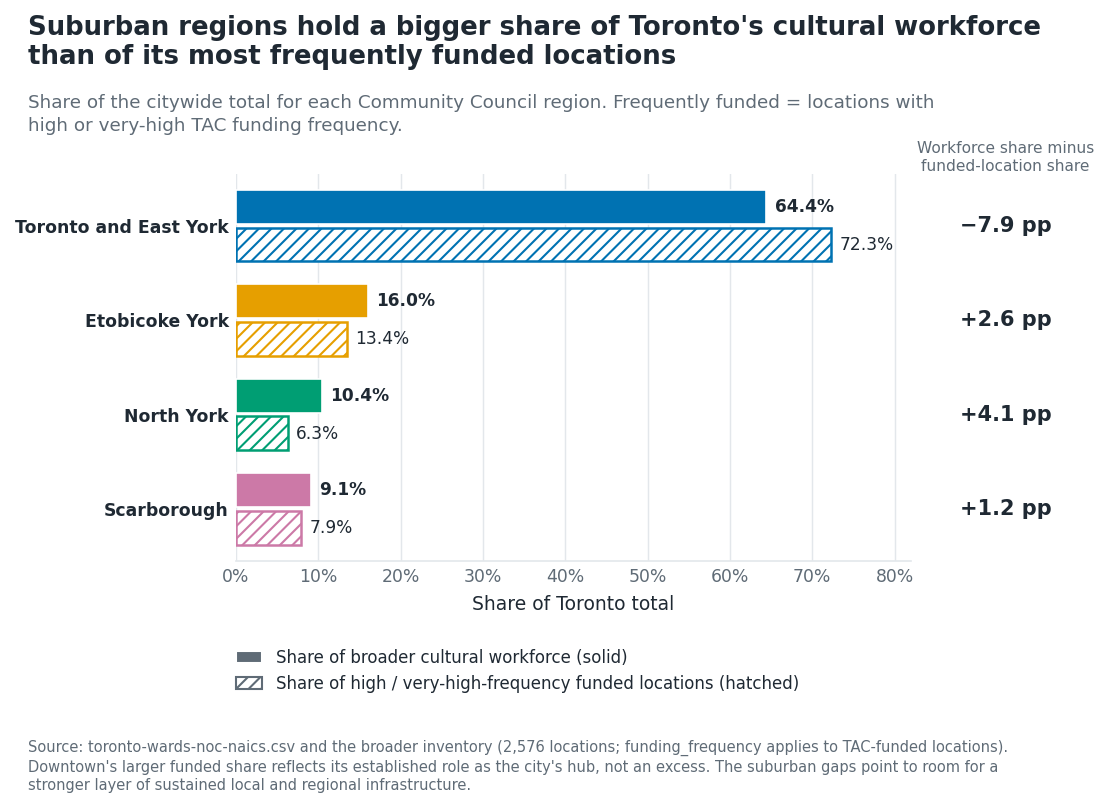

In [10]:
def plot_regional_workforce_vs_funding(rs):
    fig = plt.figure(figsize=(FIG_W, 5.3))
    top = title_block(fig, "Suburban regions hold a bigger share of Toronto's cultural workforce than of its most frequently funded locations",
                      "Share of the citywide total for each Community Council region. Frequently funded = locations with high or very-high TAC funding frequency.",
                      title_wrap=70)
    fig.subplots_adjust(left=0.20, right=0.80, top=top - 0.025, bottom=0.30)
    ax = fig.add_subplot(111)
    n = len(REGION_ORDER)
    ax.set_xlim(0, 82)
    ax.set_ylim(-0.55, n - 0.45)
    h = 0.36
    for i, region in enumerate(REGION_ORDER):
        yc = n - 1 - i
        c = REGION_COLORS[region]
        wf, fl = rs.loc[region, "workforce"] * 100, rs.loc[region, "high_frequency_locations"] * 100
        ax.barh(yc + h / 2 + 0.02, wf, height=h, color=c, edgecolor=SURFACE, linewidth=0.8, zorder=2)
        ax.barh(yc - h / 2 - 0.02, fl, height=h, facecolor=SURFACE, edgecolor=c, hatch="////", linewidth=1.2, zorder=2)
        ax.text(wf + 1.0, yc + h / 2 + 0.02, f"{wf:.1f}%", va="center", fontsize=8.2, fontweight="bold")
        ax.text(fl + 1.0, yc - h / 2 - 0.02, f"{fl:.1f}%", va="center", fontsize=8.2)
        gap = rs.loc[region, "gap_pp"]
        ax.text(1.14, yc, f"{gap:+.1f} pp".replace("-", "\u2212"), transform=ax.get_yaxis_transform(), ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(1.14, n - 0.45, "Workforce share minus\nfunded-location share", transform=ax.get_yaxis_transform(), ha="center", va="bottom", fontsize=7.4,
            color=MUTED, linespacing=1.2)
    ax.set_yticks([n - 1 - i for i in range(n)])
    ax.set_yticklabels(REGION_ORDER)
    for lab, region in zip(ax.get_yticklabels(), REGION_ORDER):
        lab.set_fontweight("bold")
    ax.xaxis.set_major_formatter(pct_fmt())
    ax.set_xlabel("Share of Toronto total")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    handles = [Patch(facecolor=MUTED, edgecolor=SURFACE, label="Share of broader cultural workforce (solid)"),
               Patch(facecolor=SURFACE, edgecolor=MUTED, hatch="////", label="Share of high / very-high-frequency funded locations (hatched)")]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.45, 0.115), ncol=1, fontsize=8, handlelength=1.6)
    source_note(fig, "Source: toronto-wards-noc-naics.csv and the broader inventory (2,576 locations; funding_frequency applies to TAC-funded locations). Downtown's "
                     "larger funded share reflects its established role as the city's hub, not an excess. The suburban gaps point to room for a stronger "
                     "layer of sustained local and regional infrastructure.", wrap=140)
    plt.show()


plot_regional_workforce_vs_funding(region_share)

**What it shows.** For each of the four Community Council regions, its share of Toronto’s broader cultural workforce (solid bar) and its share of high- or very-high-frequency funded locations (hatched bar), with the percentage-point gap on the right.

| Region | Workforce share | High-frequency location share | Gap |
|---|---|---|---|
| Toronto and East York | 64.4% | 72.3% | −7.9 pp |
| Etobicoke York | 16.0% | 13.4% | +2.6 pp |
| North York | 10.4% | 6.3% | +4.1 pp |
| Scarborough | 9.1% | 7.9% | +1.2 pp |

**Narrative claim.** In all three suburban regions the workforce share exceeds the share of frequently funded locations (together about 36% versus 28%). These are opportunities to build sustained local and regional infrastructure, not evidence of a shortfall in the downtown core, where the funded-location share is larger than the workforce share precisely because the region anchors the city’s network.

**Limitations.**
- “High-frequency funded” counts locations that receive TAC funding often. It is not funding dollars, and it does not show a funding effect.
- Suburban regions hold about 67.5% of residents but 35.6% of the workforce, so workforce is itself concentrated downtown; the gaps here compare two measures of cultural presence, not residents.
- Region-level gaps hide ward-level differences, which the next sections examine.

**Primary vs. alternative.** One paired-bar design is enough here. Hatching plus tint keeps the two measures distinct without a second colour scheme or a dual axis, and the gap column keeps the message to a single number per region.

## 3. Workforce versus infrastructure

**Claim to support:** cultural-worker count and the number of locations in the broader inventory rise together across wards (Spearman ρ of about 0.73), so the story is about a few **exceptions**, not a general mismatch.

This section computes the two trend-based measures used again in Section 4: the citywide workforce–location trend, and the average workforce and infrastructure ranks (rank 1 = highest level).

In [11]:
# --- (b) rank method: average workforce rank vs average infrastructure rank (rank 1 = highest) ---
rank_gap = compare[["ward_name", "region"]].copy()
rank_gap["rank_workers"] = compare[f"{HEADLINE_MEASURE}_count"].rank(ascending=False, method="min")
rank_gap["rank_artists"] = compare[f"{ARTIST_MEASURE_ALT}_count"].rank(ascending=False, method="min")
rank_gap["rank_worker_concentration"] = compare[f"{HEADLINE_MEASURE}_pct"].rank(ascending=False, method="min")
rank_gap["rank_locations"] = compare["n_locations"].rank(ascending=False, method="min")
rank_gap["rank_locations_per_resident"] = compare["locations_per_100k"].rank(ascending=False, method="min")
rank_gap["rank_tac_funded"] = compare["n_tac_funded"].rank(ascending=False, method="min")
rank_gap["rank_free_programming"] = compare["meaningful_free_programming_share"].rank(ascending=False, method="min")
rank_gap["avg_workforce_rank"] = rank_gap[["rank_workers", "rank_artists", "rank_worker_concentration"]].mean(axis=1)
rank_gap["avg_infra_rank"] = rank_gap[["rank_locations", "rank_locations_per_resident", "rank_tac_funded", "rank_free_programming"]].mean(axis=1)
rank_gap["rank_gap"] = rank_gap["avg_infra_rank"] - rank_gap["avg_workforce_rank"]     # positive = workforce outranks infrastructure

# --- (c) deviation from the citywide workforce-location trend (log-log fit of locations on workers) ---
log_workers, log_locations = np.log1p(compare[f"{HEADLINE_MEASURE}_count"]), np.log1p(compare["n_locations"])
trend_slope, trend_intercept = np.polyfit(log_workers, log_locations, 1)
compare["residual_log_locations"] = log_locations - (trend_slope * log_workers + trend_intercept)   # negative = fewer locations than trend

# the scatterplot draws the same relation fitted the other way round (workers on locations), which reads naturally with locations on the x-axis
plot_slope, plot_intercept = np.polyfit(log_locations, log_workers, 1)
compare["residual_log_workers"] = log_workers - (plot_slope * log_locations + plot_intercept)    # positive = more workers than the trend implies


rho_workers_locations = spearmanr(compare[f"{HEADLINE_MEASURE}_count"], compare["n_locations"])[0]
print(f"Spearman rho, cultural-worker count vs total locations: {rho_workers_locations:.2f}")
trend_check = compare.set_index("ward_name").loc[HIGHLIGHT_WARDS, ["residual_log_locations", "residual_log_workers"]]
trend_check["rank_among_main_cases_by_shortfall"] = trend_check.loc[MAIN_CASE_WARDS, "residual_log_locations"].rank()
display(trend_check.round(3))

Spearman rho, cultural-worker count vs total locations: 0.73


,residual_log_locations,residual_log_workers,rank_among_main_cases_by_shortfall
ward_name,,,
Don Valley North,-0.592,0.587,1.000
Willowdale,-0.445,0.483,2.000
Eglinton-Lawrence,-0.226,0.263,3.000
Don Valley West,-0.204,0.242,NaN


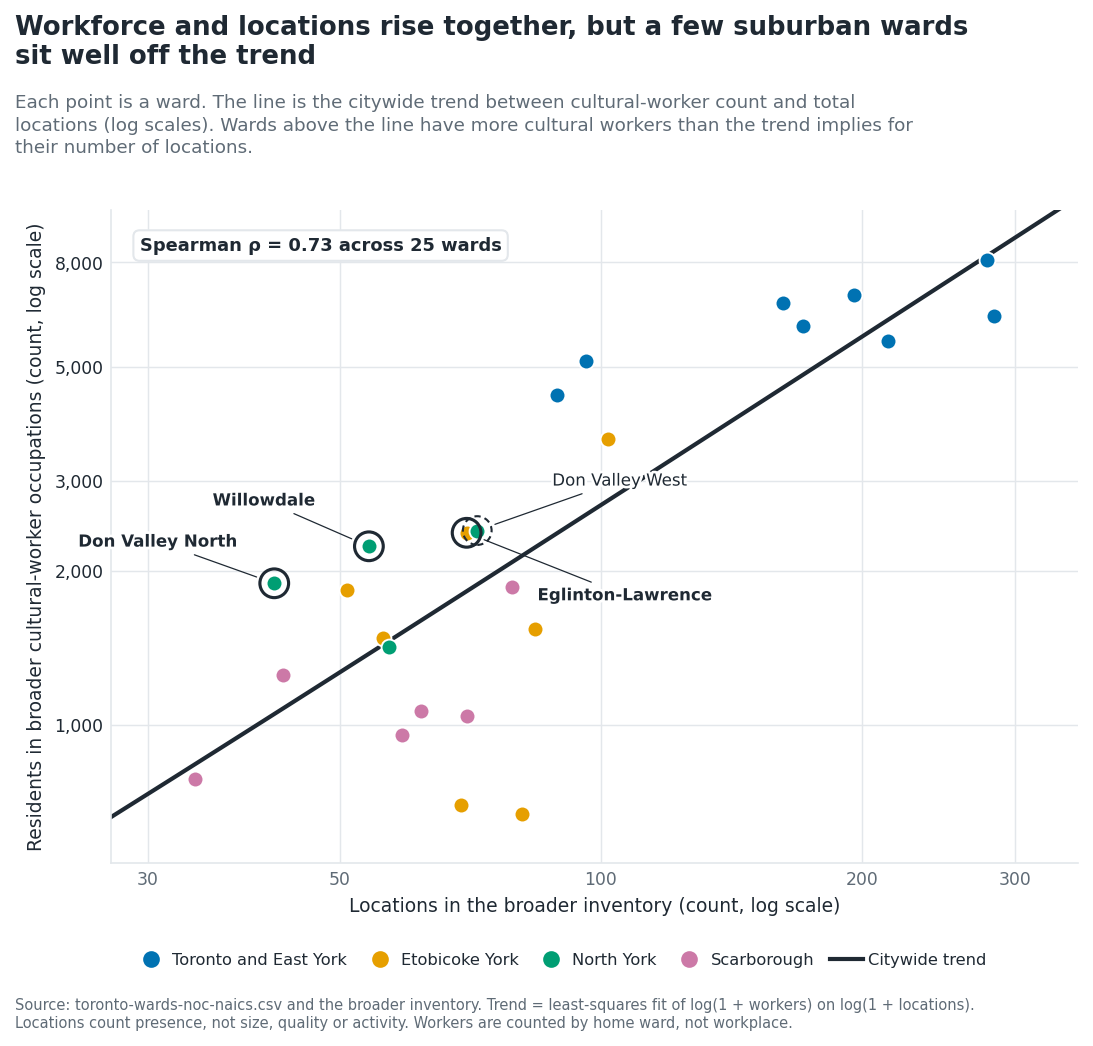

In [12]:
def plot_workforce_vs_locations(df, rho):
    xcol, ycol = "n_locations", f"{HEADLINE_MEASURE}_count"
    fig = plt.figure(figsize=(FIG_W, 6.9))
    top = title_block(fig, "Workforce and locations rise together, but a few suburban wards sit well off the trend",
                      "Each point is a ward. The line is the citywide trend between cultural-worker count and total locations (log scales). "
                      "Wards above the line have more cultural workers than the trend implies for their number of locations.")
    fig.subplots_adjust(left=0.10, right=0.96, top=top - 0.03, bottom=0.17)
    ax = fig.add_subplot(111)
    ax.set_xscale("log")
    ax.set_yscale("log")
    x_lo, x_hi = df[xcol].min() * 0.8, df[xcol].max() * 1.25
    y_lo, y_hi = df[ycol].min() * 0.8, df[ycol].max() * 1.25
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    xs = np.geomspace(x_lo, x_hi, 100)       # least-squares fit of log(1 + workers) on log(1 + locations)
    ax.plot(xs, np.expm1(plot_slope * np.log1p(xs) + plot_intercept), color=TREND_COLOR, linewidth=2.0, zorder=2, label="Citywide trend")
    for region in REGION_ORDER:
        s = df["region"] == region
        ax.scatter(df.loc[s, xcol], df.loc[s, ycol], s=58, color=REGION_COLORS[region], edgecolor=SURFACE, linewidth=0.9, zorder=3, label=region)
    for w in HIGHLIGHT_WARDS:
        r = df[df["ward_name"] == w].iloc[0]
        ax.scatter(r[xcol], r[ycol], s=190, facecolor="none", edgecolor=INK, linewidth=1.5 if w in MAIN_CASE_WARDS else 1.0,
                   linestyle="-" if w in MAIN_CASE_WARDS else (0, (3, 2)), zorder=4)
        dx, dy, ha = SCATTER_LABEL_OFFSETS[w]
        ax.annotate(f"{w}", (r[xcol], r[ycol]), xytext=(dx, dy), textcoords="offset points", ha=ha, va="center", fontsize=8, path_effects=HALO, zorder=6,
                    fontweight="bold" if w in MAIN_CASE_WARDS else "normal",
                    arrowprops=dict(arrowstyle="-", color=INK, linewidth=0.6, shrinkA=0, shrinkB=9))
    xt = [v for v in (20, 30, 50, 100, 200, 300, 500) if x_lo < v < x_hi]
    yt = [v for v in (500, 1000, 2000, 3000, 5000, 8000) if y_lo < v < y_hi]
    ax.set_xticks(xt)
    ax.set_yticks(yt)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.minorticks_off()
    ax.set_xlabel("Locations in the broader inventory (count, log scale)")
    ax.set_ylabel("Residents in broader cultural-worker occupations (count, log scale)")
    style_axes(ax, "both")
    ax.text(0.03, 0.96, f"Spearman \u03c1 = {rho:.2f} across 25 wards", transform=ax.transAxes, va="top", fontsize=8.6, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE, edgecolor=GRID_COLOR))
    handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7, color=REGION_COLORS[r], label=r) for r in REGION_ORDER]
    handles.append(Line2D([0], [0], color=TREND_COLOR, linewidth=2, label="Citywide trend"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.055), ncol=5, fontsize=7.8, handletextpad=0.3, columnspacing=1.0)
    source_note(fig, "Source: toronto-wards-noc-naics.csv and the broader inventory. Trend = least-squares fit of log(1 + workers) on log(1 + locations). Locations count presence, not size, "
                     "quality or activity. Workers are counted by home ward, not workplace.", wrap=140)
    plt.show()


plot_workforce_vs_locations(compare, rho_workers_locations)

**What it shows.** Each ward as a point (total locations on the x-axis, cultural-worker count on the y-axis, both on log scales) with a clearly visible citywide trend line and the four case wards labelled. Wards above the line have more cultural workers than the trend implies for their number of locations. Median reference lines were left off because they added clutter without clarifying the trend.

**Narrative claim.** Spearman ρ between cultural-worker count and total locations is about 0.73. Don Valley North and Willowdale fall furthest from the trend among the main suburban cases: relative to the trend they have roughly 1.8× and 1.6× the workers implied by their location counts, compared with about 1.3× for Eglinton-Lawrence and Don Valley West. Eglinton-Lawrence shows a smaller mismatch because its raw inventory is larger (70 locations, against 42 in Don Valley North and 54 in Willowdale).

**Limitations.**
- A log-log trend over 25 wards is descriptive, not a model of how many locations a workforce “should” have, and several wards fall far from the line.
- The inventory counts presence, not size, quality or activity.
- The line here regresses workers on locations; the Section 4 trend-deviation method fits the same relationship the other way round. Both rank the four case wards in the same order (Don Valley North, Willowdale, Eglinton-Lawrence, Don Valley West).

**Primary vs. alternative.** The scatter is the stronger graphic for councillors: it needs one sentence of explanation, shows the whole city and places the case wards within it.

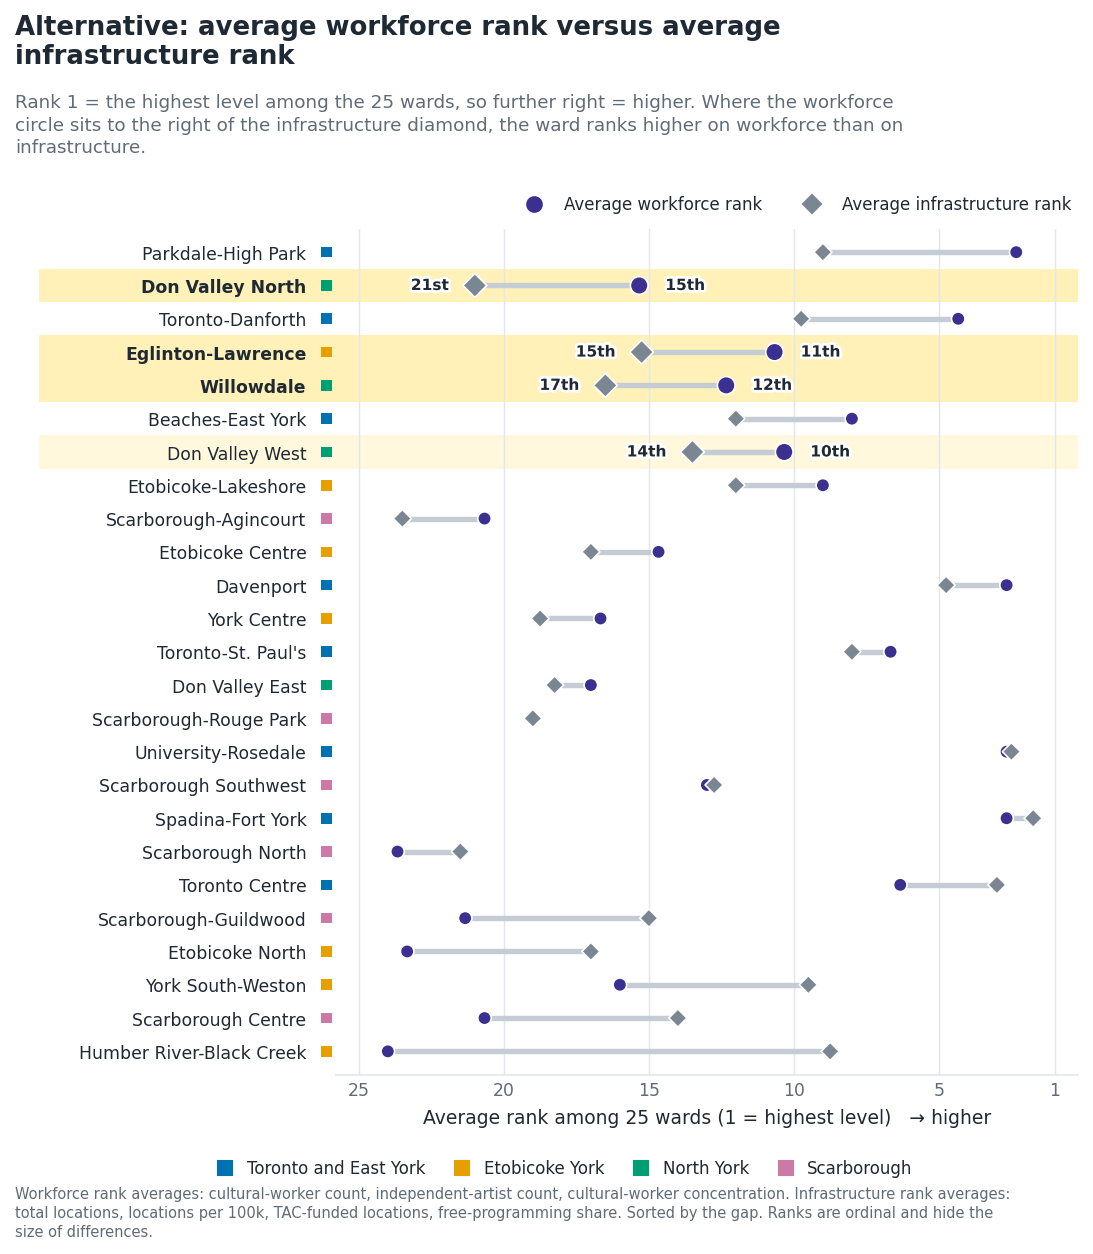

In [13]:
def plot_rank_dumbbell(rk):
    d = rk.sort_values("rank_gap", ascending=True).reset_index(drop=True)       # biggest workforce-over-infrastructure gap at the top
    wards, y = d["ward_name"].tolist(), np.arange(len(d))
    fig = plt.figure(figsize=(FIG_W, 8.3))
    top = title_block(fig, "Alternative: average workforce rank versus average infrastructure rank",
                      "Rank 1 = the highest level among the 25 wards, so further right = higher. Where the workforce circle sits to the right of "
                      "the infrastructure diamond, the ward ranks higher on workforce than on infrastructure.")
    fig.subplots_adjust(left=0.30, right=0.96, top=top - 0.04, bottom=0.14)
    ax = fig.add_subplot(111)
    ax.set_xlim(25.8, 0.2)                                      # inverted: rank 1 (highest) at the right
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(wards)
    highlight_rows(ax, wards, highlight=MAIN_CASE_WARDS, x0=-0.40)
    for i, w in enumerate(wards):
        if w in SECONDARY_WARDS:
            ax.add_patch(Rectangle((-0.40, i - 0.5), 1.40, 1, transform=ax.get_yaxis_transform(), facecolor=HIGHLIGHT_BAND_SECONDARY, edgecolor="none", clip_on=False, zorder=0))
    ax.hlines(y, d["avg_workforce_rank"], d["avg_infra_rank"], color=LINK_COLOR, linewidth=2.6, zorder=1)
    hl = d["ward_name"].isin(HIGHLIGHT_WARDS).values
    ax.scatter(d["avg_workforce_rank"], y, s=np.where(hl, 72, 42), color=WORKFORCE_COLOR, edgecolor=SURFACE, linewidth=0.8, zorder=3, marker="o")
    ax.scatter(d["avg_infra_rank"], y, s=np.where(hl, 66, 38), color=INFRA_COLOR, edgecolor=SURFACE, linewidth=0.8, zorder=3, marker="D")
    for yi, wr, ir, h in zip(y, d["avg_workforce_rank"], d["avg_infra_rank"], hl):
        if h:
            for val, other, nm in ((wr, ir, "w"), (ir, wr, "i")):
                toward_left = val > other        # larger rank number sits further left on the inverted axis
                ax.text(val + (0.9 if toward_left else -0.9), yi, ordinal(val), ha="right" if toward_left else "left", va="center", fontsize=7.4,
                        fontweight="bold", path_effects=HALO, zorder=4)
    ax.set_xticks([25, 20, 15, 10, 5, 1])
    ax.tick_params(axis="y", pad=14)
    region_markers(ax, wards, x=-0.012)
    ax.set_xlabel("Average rank among 25 wards (1 = highest level)   \u2192 higher")
    style_axes(ax, "x")
    ax.spines["left"].set_visible(False)
    handles = [Line2D([0], [0], marker="o", linestyle="", color=WORKFORCE_COLOR, markersize=7, label="Average workforce rank"),
               Line2D([0], [0], marker="D", linestyle="", color=INFRA_COLOR, markersize=6, label="Average infrastructure rank")]
    ax.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.0, 1.01), ncol=2, fontsize=8, borderaxespad=0)
    region_legend(fig, y=0.045)
    source_note(fig, "Workforce rank averages: cultural-worker count, independent-artist count, cultural-worker concentration. Infrastructure rank averages: total "
                     "locations, locations per 100k, TAC-funded locations, free-programming share. Sorted by the gap. Ranks are ordinal and hide the size of differences.", wrap=135)
    plt.show()


plot_rank_dumbbell(rank_gap)

**What it shows.** For each ward, its average workforce rank (circle) and average infrastructure rank (diamond) among the 25 wards, with rank 1 meaning the highest level and plotted on the right. Wards are sorted by the gap, with the biggest gap between workforce and infrastructure rank at the top.

**Narrative claim.** Don Valley North, Eglinton-Lawrence and Willowdale all rank higher on workforce than on infrastructure (for example Don Valley North is 15th on workforce but 21st on infrastructure).

**Limitations.** Ranks are ordinal and hide the size of differences. The same method surfaces downtown wards with large rank gaps (Parkdale-High Park has the largest gap of any ward, and Toronto-Danforth’s is larger than those of Eglinton-Lawrence and Willowdale), which dilutes the focus: those wards combine very high workforce ranks with only middling infrastructure ranks, and the quadrant and trend methods screen them out.

**Primary vs. alternative.** For a councillor audience the rank version is **more abstract and less focused** than the scatter, and it needs an explicit “rank 1 = highest” note. It is better suited to an appendix or an interactive view.

## 4. How the opportunity wards were selected

This section is a compact explanation, not a methods presentation.

- **12 initial comparisons** combine three workforce measures (creative occupations, broader cultural workers, independent artists) with four infrastructure measures (total locations, locations per 100,000 residents, TAC-funded locations, venues in the activity sample).
- **A ward is flagged in a comparison** when it is at or above the citywide median on workforce and at or below the median on infrastructure.
- **Two further methods** compare workforce and infrastructure *ranks* (top quartile of the rank gap) and measure *deviation from the citywide workforce–location trend* (bottom quartile of the residual). Together with a quadrant rule (flagged in at least half of the 12 comparisons) these form the three “broader methods”.

No composite score is created: each comparison and method stays visible and separate.

In [14]:
# --- (a) quadrant method: above-median workforce AND at-or-below-median infrastructure, 12 comparisons ----
combos = list(product(WORKFORCE_COLS_FOR_QUADRANT, INFRA_COLS_FOR_QUADRANT))
flag_matrix = pd.DataFrame(index=compare["ward_name"], columns=pd.MultiIndex.from_tuples(combos), dtype=bool)
for wf_col, infra_col in tqdm(combos, desc="12 workforce x infrastructure comparisons"):
    hit = (compare[wf_col] >= compare[wf_col].median()) & (compare[infra_col] <= compare[infra_col].median())
    flag_matrix[(wf_col, infra_col)] = hit.values
n_flagged = flag_matrix.sum(axis=1).rename("n_comparisons_flagged")


# --- robustness: how many of the three broader methods flag each ward --------------------------
robustness = pd.DataFrame({
    "n_comparisons_flagged": n_flagged,
    "flag_quadrant": (n_flagged / len(combos)) >= QUADRANT_SHARE_THRESHOLD,
}).reset_index().rename(columns={"index": "ward_name"})
robustness = robustness.merge(rank_gap[["ward_name", "rank_gap"]], on="ward_name").merge(compare[["ward_name", "residual_log_locations"]], on="ward_name")
robustness["flag_rank_gap"] = robustness["rank_gap"] >= rank_gap["rank_gap"].quantile(RANK_GAP_QUANTILE)
robustness["flag_residual"] = robustness["residual_log_locations"] <= compare["residual_log_locations"].quantile(RESIDUAL_QUANTILE)
robustness["n_methods"] = robustness[["flag_quadrant", "flag_rank_gap", "flag_residual"]].sum(axis=1)
robustness = robustness.set_index("ward_name")

print(f"highest comparison count among all other wards: {int(n_flagged.drop(HIGHLIGHT_WARDS).max())} of {len(combos)} "
      f"({n_flagged.drop(HIGHLIGHT_WARDS).idxmax()})")
display(robustness.loc[HIGHLIGHT_WARDS, ["n_comparisons_flagged", "flag_quadrant", "flag_rank_gap", "flag_residual", "n_methods"]])
main_checks_selection = [("Spearman rho, cultural workers vs total locations", rho_workers_locations)]
for w in HIGHLIGHT_WARDS:
    main_checks_selection += [(f"{w}: comparisons flagging (of 12)", robustness.loc[w, "n_comparisons_flagged"]),
                              (f"{w}: broader methods flagging (of 3)", robustness.loc[w, "n_methods"])]
checks_selection = run_checks(main_checks_selection)

12 workforce x infrastructure comparisons:   0%|          | 0/12 [00:00<?, ?it/s]

highest comparison count among all other wards: 2 of 12 (Scarborough Southwest)


,n_comparisons_flagged,flag_quadrant,flag_rank_gap,flag_residual,n_methods
ward_name,,,,,
Don Valley North,8,True,True,True,3
Willowdale,12,True,True,True,3
Eglinton-Lawrence,12,True,True,False,2
Don Valley West,9,True,True,False,2


check,computed,expected,status
"Spearman rho, cultural workers vs total locations",0.728,0.730,OK
Don Valley North: comparisons flagging (of 12),8.000,8.000,OK
Don Valley North: broader methods flagging (of 3),3.000,3.000,OK
Willowdale: comparisons flagging (of 12),12.000,12.000,OK
Willowdale: broader methods flagging (of 3),3.000,3.000,OK
Eglinton-Lawrence: comparisons flagging (of 12),12.000,12.000,OK
Eglinton-Lawrence: broader methods flagging (of 3),2.000,2.000,OK
Don Valley West: comparisons flagging (of 12),9.000,9.000,OK
Don Valley West: broader methods flagging (of 3),2.000,2.000,OK


9/9 validation checks within tolerance


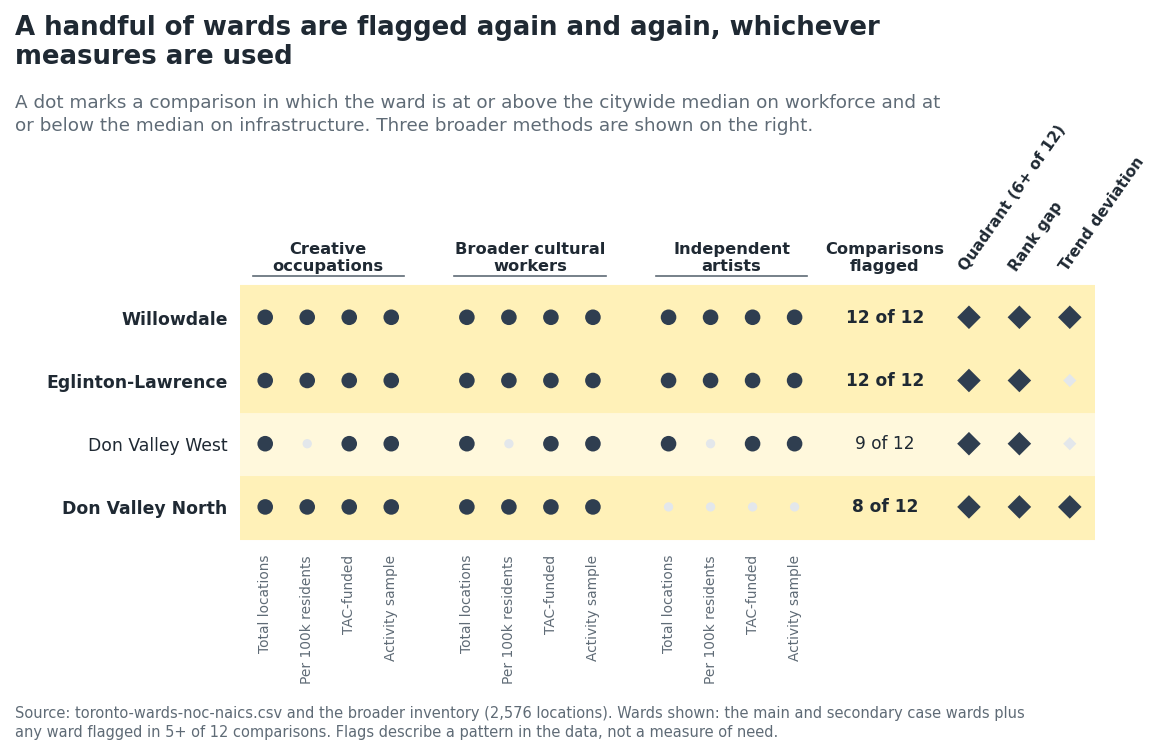

In [15]:
def plot_selection_matrix(flags, rob):
    combos_ = list(flags.columns)
    shown = [w for w in rob.index if w in HIGHLIGHT_WARDS or rob.loc[w, "n_comparisons_flagged"] >= MATRIX_CANDIDATE_MIN_FLAGS]
    shown = sorted(shown, key=lambda w: (-rob.loc[w, "n_comparisons_flagged"], -rob.loc[w, "n_methods"], w))
    n = len(shown)
    k = len(INFRA_COLS_FOR_QUADRANT)
    xs, group_centres, x = [], [], 0.0
    for _ in WORKFORCE_COLS_FOR_QUADRANT:       # three groups of four columns, one group per workforce measure
        xs += [x + i for i in range(k)]
        group_centres.append(x + (k - 1) / 2)
        x += k + 0.8
    x_count = x + 0.35
    method_x = [x_count + 2.0, x_count + 3.2, x_count + 4.4]
    methods = [("flag_quadrant", f"Quadrant ({int(QUADRANT_SHARE_THRESHOLD * len(combos_))}+ of {len(combos_)})"), ("flag_rank_gap", "Rank gap"), ("flag_residual", "Trend deviation")]

    fig = plt.figure(figsize=(FIG_W, 3.9 + 0.26 * n))
    top = title_block(fig, "A handful of wards are flagged again and again, whichever measures are used",
                      "A dot marks a comparison in which the ward is at or above the citywide median on workforce and at or below the median on "
                      "infrastructure. Three broader methods are shown on the right.")
    fig.subplots_adjust(left=0.215, right=0.975, top=top - 0.17, bottom=0.27)
    ax = fig.add_subplot(111)
    ax.set_xlim(-0.6, method_x[-1] + 0.6)
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_yticks(range(n))
    ax.set_yticklabels(shown[::-1])
    for i, w in enumerate(shown[::-1]):
        if w in HIGHLIGHT_WARDS:
            ax.axhspan(i - 0.5, i + 0.5, color=HIGHLIGHT_BAND if w in MAIN_CASE_WARDS else HIGHLIGHT_BAND_SECONDARY, zorder=0)
        for (wf, infra), cx in zip(combos_, xs):
            on = bool(flags.loc[w, (wf, infra)])
            ax.scatter(cx, i, s=56 if on else 20, color=FLAG_COLOR if on else GRID_COLOR, zorder=3, edgecolor="none")
        ax.text(x_count, i, f"{int(rob.loc[w, 'n_comparisons_flagged'])} of {len(combos_)}", ha="center", va="center", fontsize=8.2,
                fontweight="bold" if w in MAIN_CASE_WARDS else "normal")
        for mx, (col, _) in zip(method_x, methods):
            on = bool(rob.loc[w, col])
            ax.scatter(mx, i, s=64 if on else 20, marker="D", color=FLAG_COLOR if on else GRID_COLOR, zorder=3, edgecolor="none")
    for lab in ax.get_yticklabels():
        if lab.get_text() in MAIN_CASE_WARDS:
            lab.set_fontweight("bold")
    for gc, wf in zip(group_centres, WORKFORCE_COLS_FOR_QUADRANT):         # headers: workforce measure above, infrastructure measure rotated below
        ax.text(gc, n - 0.3, WORKFORCE_SHORT[wf.replace("_count", "")], ha="center", va="bottom", fontsize=7.8, fontweight="bold", clip_on=False, linespacing=1.15)
        ax.plot([gc - 1.8, gc + 1.8], [n - 0.35, n - 0.35], color=MUTED, linewidth=0.8, clip_on=False)
    for cx, (wf, infra) in zip(xs, combos_):
        ax.text(cx, -0.75, INFRA_SHORT[infra].replace("-\n", "-").replace("\n", " "), ha="center", va="top", fontsize=6.6, color=MUTED, rotation=90, clip_on=False)
    ax.text(x_count, n - 0.3, "Comparisons\nflagged", ha="center", va="bottom", fontsize=7.8, fontweight="bold", clip_on=False, linespacing=1.15)
    for mx, (_, name) in zip(method_x, methods):
        ax.text(mx, n - 0.3, name, ha="left", va="bottom", fontsize=7.4, fontweight="bold", clip_on=False, rotation=55, rotation_mode="anchor")
    ax.set_xticks([])
    ax.tick_params(axis="y", length=0, pad=6)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(False)
    source_note(fig, "Source: toronto-wards-noc-naics.csv and the broader inventory (2,576 locations). Wards shown: the main and secondary case wards plus any ward flagged "
                     f"in {MATRIX_CANDIDATE_MIN_FLAGS}+ of 12 comparisons. Flags describe a pattern in the data, not a measure of need.", wrap=135)
    plt.show()


plot_selection_matrix(flag_matrix, robustness)

**What it shows.** A dot matrix of the flagged wards. Each dot marks one of the 12 comparisons in which the ward is above the workforce median and at or below the infrastructure median; the diamonds on the right show the three broader methods.

| Ward | Comparisons flagged | Broader methods flagging |
|---|---|---|
| Willowdale | 12 of 12 | 3 of 3 |
| Eglinton-Lawrence | 12 of 12 | 2 of 3 |
| Don Valley West | 9 of 12 | 2 of 3 |
| Don Valley North | 8 of 12 | 3 of 3 |

**Narrative claim.** The same few wards recur whichever measures are used, and no other ward is flagged in more than two of the 12 comparisons. Don Valley North’s four missing dots all sit under the independent-artists measure; Don Valley West’s missing dots are the locations-per-100k comparisons, where its per-capita inventory is above the median.

**Limitations.** Median splits are blunt, and flags describe a pattern in the data, not a measure of need. Wards near the median on a measure can move in or out of a comparison.

**Primary vs. alternative.** The dot matrix is the **strongest ward-selection graphic**: it shows robustness at a glance without turning the story into a methods presentation. The Section 3 scatter remains the better explanatory graphic.

## 5. Three compact ward profiles

Three profile cards communicate three different opportunity types:

- **Don Valley North:** the clearest numerical shortfall, alongside an existing nearby suburban network.
- **Willowdale:** evidence of what an anchor institution can accomplish, alongside room for a broader ecosystem.
- **Eglinton-Lawrence:** a sizeable existing inventory that may need more sustained programming rather than simply more locations.

Each row has its own scale, so counts, rates, ranks, percentages and kilometres are never combined on one axis. **The activity rows describe all residents of these wards, not cultural workers specifically.**

In [16]:
# --- activity profile and distance for each case ward --------------------------------------
homes_dist = build_home_distances()
W = "normalized_raw_stop_count"


def ward_activity_profile(ward):
    grp = ward_to_ward_activity[ward_to_ward_activity["origin_ward"] == ward]
    total = grp[VALUE_COL].sum()
    outside = grp.loc[~grp["same_ward"]].sort_values(VALUE_COL, ascending=False)
    return {"within_share": grp.loc[grp["same_ward"], VALUE_COL].sum() / total, "outside_share": outside[VALUE_COL].sum() / total,
            "leading_dest": outside.iloc[0]["dest_ward"], "leading_dest_share": outside.iloc[0][VALUE_COL] / outside[VALUE_COL].sum()}


profiles = {}
for w in tqdm(HIGHLIGHT_WARDS, desc="ward profiles"):
    row = compare.set_index("ward_name").loc[w]
    ranks = rank_gap.set_index("ward_name").loc[w]
    q = weighted_quantiles(homes_dist[homes_dist["origin_ward"] == w], "distance_km", W)
    profiles[w] = {
        "workers": row[f"{HEADLINE_MEASURE}_count"], "workers_pct": row[f"{HEADLINE_MEASURE}_pct"], "locations": row["n_locations"],
        "per_100k": row["locations_per_100k"], "tac_funded": row["n_tac_funded"], "high_freq": row["n_high_funding_freq"],
        "workforce_rank": ranks["avg_workforce_rank"], "infra_rank": ranks["avg_infra_rank"],
        "median_km": q[0.5], "p25_km": q[0.25], "p75_km": q[0.75], **ward_activity_profile(w)}
# Willowdale's within-ward share rests heavily on one home area next to Meridian Arts Centre: quantify it
willowdale_cells = homes_dist[homes_dist["origin_ward"] == "Willowdale"].groupby("home_geohash6")[W].sum().sort_values(ascending=False)
willowdale_top_cell_share = willowdale_cells.iloc[0] / willowdale_cells.sum()
willowdale_top_cell_km = homes_dist[(homes_dist["origin_ward"] == "Willowdale") & (homes_dist["home_geohash6"] == willowdale_cells.index[0])]["distance_km"].min()
print(f"Willowdale: one home area ({willowdale_cells.index[0]}) supplies {willowdale_top_cell_share:.0%} of residents' recorded activity, "
      f"{willowdale_top_cell_km * 1000:,.0f} m from its nearest included venue")

profile_table = pd.DataFrame(profiles).T
display(profile_table.drop(columns=["leading_dest"]).astype(float).round(2).join(profile_table["leading_dest"]))

checks_profiles = run_checks([
    ("Don Valley North: cultural workers", profiles["Don Valley North"]["workers"]), ("Don Valley North: locations", profiles["Don Valley North"]["locations"]),
    ("Don Valley North: locations per 100k", profiles["Don Valley North"]["per_100k"]), ("Don Valley North: TAC-funded locations", profiles["Don Valley North"]["tac_funded"]),
    ("Don Valley North: high-frequency funded locations", profiles["Don Valley North"]["high_freq"]),
    ("Don Valley North: average workforce rank", profiles["Don Valley North"]["workforce_rank"]),
    ("Don Valley North: average infrastructure rank", profiles["Don Valley North"]["infra_rank"]),
    ("Don Valley North: residents' activity outside ward", profiles["Don Valley North"]["outside_share"]),
    ("Don Valley North: median distance (km)", profiles["Don Valley North"]["median_km"]),
    ("Willowdale: cultural workers", profiles["Willowdale"]["workers"]), ("Willowdale: locations", profiles["Willowdale"]["locations"]),
    ("Willowdale: locations per 100k", profiles["Willowdale"]["per_100k"]), ("Willowdale: TAC-funded locations", profiles["Willowdale"]["tac_funded"]),
    ("Willowdale: high-frequency funded locations", profiles["Willowdale"]["high_freq"]),
    ("Willowdale: average workforce rank", profiles["Willowdale"]["workforce_rank"]),
    ("Willowdale: average infrastructure rank", profiles["Willowdale"]["infra_rank"]),
    ("Willowdale: residents' activity within ward", profiles["Willowdale"]["within_share"]),
    ("Eglinton-Lawrence: cultural workers", profiles["Eglinton-Lawrence"]["workers"]), ("Eglinton-Lawrence: locations", profiles["Eglinton-Lawrence"]["locations"]),
    ("Eglinton-Lawrence: locations per 100k", profiles["Eglinton-Lawrence"]["per_100k"]), ("Eglinton-Lawrence: TAC-funded locations", profiles["Eglinton-Lawrence"]["tac_funded"]),
    ("Eglinton-Lawrence: high-frequency funded locations", profiles["Eglinton-Lawrence"]["high_freq"]),
    ("Eglinton-Lawrence: average workforce rank", profiles["Eglinton-Lawrence"]["workforce_rank"]),
    ("Eglinton-Lawrence: average infrastructure rank", profiles["Eglinton-Lawrence"]["infra_rank"]),
    ("Eglinton-Lawrence: residents' activity outside ward", profiles["Eglinton-Lawrence"]["outside_share"]),
    ("Eglinton-Lawrence: median distance (km)", profiles["Eglinton-Lawrence"]["median_km"]),
])
print(f"Eglinton-Lawrence leading outside destination: {profiles['Eglinton-Lawrence']['leading_dest']} "
      f"({profiles['Eglinton-Lawrence']['leading_dest_share']:.0%} of its outside-ward activity)")

decoding home geohash6 cells:   0%|          | 0/1187 [00:00<?, ?it/s]

home cells with no ward match (excluded from distance summaries): 291 / 14745 rows


ward profiles:   0%|          | 0/4 [00:00<?, ?it/s]

Willowdale: one home area (dpz8bz) supplies 64% of residents' recorded activity, 84 m from its nearest included venue


,workers,workers_pct,locations,per_100k,tac_funded,high_freq,workforce_rank,infra_rank,median_km,p25_km,p75_km,within_share,outside_share,leading_dest_share,leading_dest
Don Valley North,"1,892.270",1.900,42.000,36.950,33.000,3.000,15.330,21.000,4.580,0.910,13.440,0.370,0.630,0.540,Willowdale
Willowdale,"2,234.410",2.200,54.000,45.680,50.000,7.000,12.330,16.500,0.080,0.080,0.990,0.940,0.060,0.480,University-Rosedale
Eglinton-Lawrence,"2,373.960",2.500,70.000,60.430,58.000,5.000,10.670,15.250,5.410,2.260,7.460,0.260,0.740,0.420,Willowdale
Don Valley West,"2,397.860",2.900,72.000,70.620,63.000,2.000,10.330,13.500,4.470,1.890,7.850,0.000,1.000,0.540,Willowdale


check,computed,expected,status
Don Valley North: cultural workers,"1,892.275","1,892.000",OK
Don Valley North: locations,42.000,42.000,OK
Don Valley North: locations per 100k,36.951,37.000,OK
Don Valley North: TAC-funded locations,33.000,33.000,OK
Don Valley North: high-frequency funded locations,3.000,3.000,OK
Don Valley North: average workforce rank,15.333,15.000,OK
Don Valley North: average infrastructure rank,21.000,21.000,OK
Don Valley North: residents' activity outside ward,0.631,0.630,OK
Don Valley North: median distance (km),4.584,4.600,OK
Willowdale: cultural workers,"2,234.406","2,234.000",OK


26/26 validation checks within tolerance
Eglinton-Lawrence leading outside destination: Willowdale (42% of its outside-ward activity)


In [17]:
# --- citywide ranges for each card indicator (so every dot can be placed on its own scale) ---
ward_median_km = pd.Series({w: weighted_quantiles(g, "distance_km", W)[0.5] for w, g in tqdm(homes_dist.groupby("origin_ward"), desc="ward median distances")})
ward_outside_share = ward_to_ward_summary.set_index("origin_ward")["pct_outside_ward"]
ward_view = compare.set_index("ward_name").join(rank_gap.set_index("ward_name")[["avg_workforce_rank", "avg_infra_rank"]]).join(
    ward_median_km.rename("median_km")).join(ward_outside_share.rename("outside_share"))
display(ward_view[["median_km", "outside_share"]].describe().round(2).T)

ward median distances:   0%|          | 0/25 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
median_km,25.000,6.570,4.370,0.080,4.170,5.840,10.020,15.900
outside_share,25.000,0.730,0.240,0.060,0.630,0.780,0.910,1.000


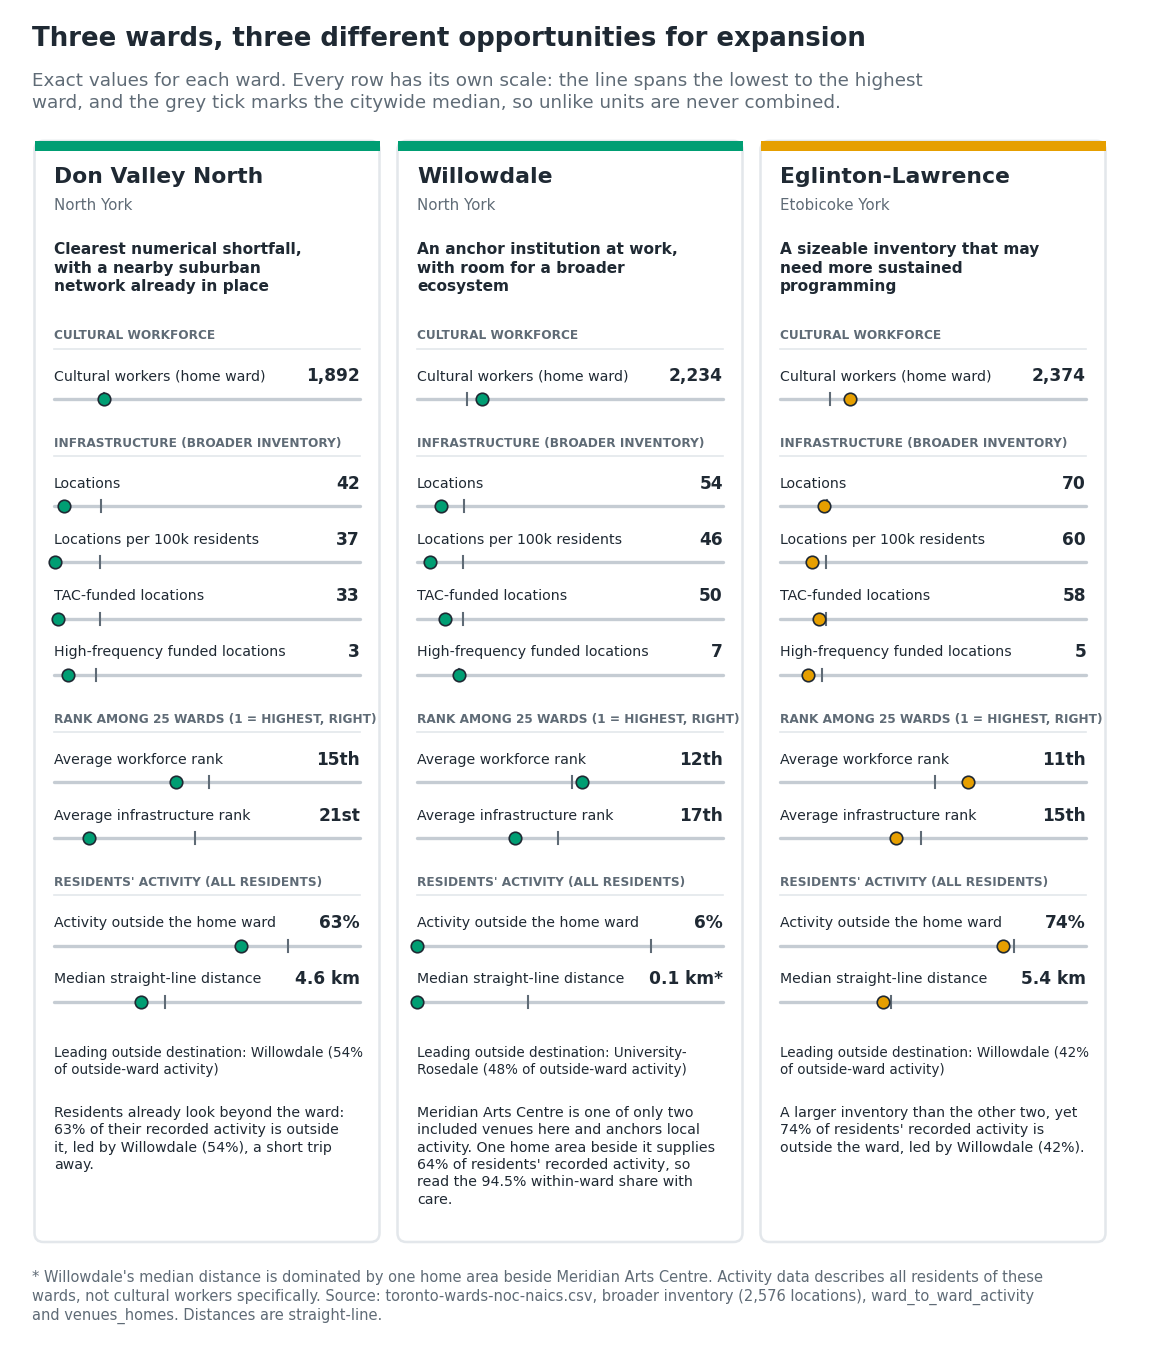

In [18]:
def plot_profile_cards(prof, view):
    wards = MAIN_CASE_WARDS
    H = 8.8
    fig = plt.figure(figsize=(FIG_W, H))
    top = title_block(fig, "Three wards, three different opportunities for expansion",
                      "Exact values for each ward. Every row has its own scale: the line spans the lowest to the highest ward, and the grey tick marks the "
                      "citywide median, so unlike units are never combined.")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, FIG_W)
    ax.set_ylim(0, H)
    ax.set_axis_off()
    y_top = top * H - 0.06
    cw, gap_, x0, pad = 2.30, 0.12, 0.13, 0.13
    row_h, head_h, card_bottom = 0.375, 0.27, 0.62
    for ci, w in enumerate(wards):
        x = x0 + ci * (cw + gap_)
        p = prof[w]
        region = WARD_REGION[w]
        lx, rx = x + pad, x + cw - pad
        ax.add_patch(FancyBboxPatch((x, card_bottom), cw, y_top - card_bottom, boxstyle="round,pad=0,rounding_size=0.06", facecolor=SURFACE, edgecolor=GRID_COLOR,
                                    linewidth=1.2, zorder=1))
        ax.add_patch(Rectangle((x, y_top - 0.07), cw, 0.07, facecolor=REGION_COLORS[region], edgecolor="none", zorder=2))
        yy = y_top - 0.24
        ax.text(lx, yy, w, fontsize=10.5, fontweight="bold", va="center", ha="left")
        yy -= 0.19
        ax.text(lx, yy, region, fontsize=7.2, color=MUTED, va="center", ha="left")
        yy -= 0.42
        ax.text(lx, yy, CASE_TYPE_LABELS[w], fontsize=7.4, fontweight="bold", va="center", ha="left", linespacing=1.3)
        yy -= 0.45
        for title, rows in CARD_SECTIONS:
            ax.text(lx, yy, title, fontsize=5.8, color=MUTED, fontweight="bold", va="center", ha="left")
            ax.plot([lx, rx], [yy - 0.085, yy - 0.085], color=GRID_COLOR, linewidth=0.8, zorder=2)
            yy -= head_h
            for key, label, fmt, col, reverse in rows:
                v = p[key]
                series = view[col]
                lo, hi = (series.max(), series.min()) if reverse else (series.min(), series.max())      # reversed: best rank on the right
                ax.text(lx, yy, label, fontsize=6.8, va="center", ha="left")
                ax.text(rx, yy, format_value(fmt, v) + ("*" if (w == "Willowdale" and key == "median_km") else ""), fontsize=8.2, fontweight="bold", va="center", ha="right")
                ty = yy - 0.15
                ax.plot([lx, rx], [ty, ty], color=LINK_COLOR, linewidth=1.6, solid_capstyle="round", zorder=2)
                pos = lambda val: lx + (val - lo) / (hi - lo) * (rx - lx)
                ax.plot([pos(series.median())] * 2, [ty - 0.04, ty + 0.04], color=MUTED, linewidth=1.0, zorder=3)
                ax.scatter(pos(v), ty, s=36, color=REGION_COLORS[region], edgecolor=INK, linewidth=0.8, zorder=4)
                yy -= row_h
            yy -= 0.07
        ax.text(lx, yy, textwrap.fill(f"Leading outside destination: {p['leading_dest']} ({p['leading_dest_share']:.0%} of outside-ward activity)", 46),
                fontsize=6.5, color=INK, va="top", ha="left", linespacing=1.3)
        note = CASE_NOTES[w].format(**p, top_cell_share=willowdale_top_cell_share)
        ax.text(lx, yy - 0.40, textwrap.fill(note, 42), fontsize=6.8, color=INK, va="top", ha="left", linespacing=1.3)
    source_note(fig, "* Willowdale's median distance is dominated by one home area beside Meridian Arts Centre. Activity data describes all residents of these wards, not "
                     "cultural workers specifically. Source: toronto-wards-noc-naics.csv, broader inventory (2,576 locations), ward_to_ward_activity and venues_homes. "
                     "Distances are straight-line.", wrap=140)
    plt.show()


plot_profile_cards(profiles, ward_view)

**What it shows.** One card per case ward with exact values and a position marker on a per-row scale (lowest to highest ward, with a grey tick at the citywide median).

| | Don Valley North | Willowdale | Eglinton-Lawrence |
|---|---|---|---|
| Cultural workers | 1,892 | 2,234 | 2,374 |
| Locations (per 100k residents) | 42 (37) | 54 (46) | 70 (60) |
| TAC-funded / high-frequency funded | 33 / 3 | 50 / 7 | 58 / 5 |
| Average workforce rank vs. infrastructure rank | 15th vs. 21st | 12th vs. 17th | 11th vs. 15th |
| Residents’ activity outside the ward | 63% | about 6% (94.5% within) | 74% |
| Median straight-line distance | 4.6 km | 0.1 km* | 5.4 km |
| Leading outside destination | Willowdale | University-Rosedale | Willowdale |

**Narrative claim.**
- **Don Valley North** shows the clearest numerical shortfall: it ranks 24th of 25 wards on locations, locations per 100,000 residents and TAC-funded locations, while its residents already look beyond the ward (63% of recorded activity), mainly to neighbouring Willowdale.
- **Willowdale** shows what an anchor institution can accomplish. Meridian Arts Centre is one of only two included venues and keeps 94.5% of residents’ recorded activity inside the ward, yet the ward still has room for a broader ecosystem (7 high-frequency funded locations and an average infrastructure rank of 17th).
- **Eglinton-Lawrence** has the largest inventory of the three (70 locations, 58 TAC-funded) but 74% of its residents’ recorded activity is outside the ward, led by Willowdale, which suggests more sustained programming may matter as much as more locations.

**Limitations.**
- \* **Willowdale’s within-ward share and 0.1 km median distance rest heavily on one home area.** One geohash cell about 84 m from Meridian Arts Centre supplies roughly 64% of Willowdale residents’ recorded activity. It may reflect residents of the adjacent buildings, staff or the way home areas are inferred, so it shows Meridian’s strong local pull but should not be read as the behaviour of Willowdale residents generally.
- The activity data describes all residents, not cultural workers; the infrastructure counts measure presence, not size or quality.
- Straight-line medians are not travel times.

**Primary vs. alternative.** See Section 6.

## 6. Optional case-study alternative: indicator matrix

If the cards feel too text-heavy, the same indicators can be shown as a matrix: one row per ward, one column per indicator, exact values in each cell and unlike units kept in separate labelled groups. Shading shows where a value falls among the 25 wards *within its own column only*; it is not a score and nothing is averaged across columns.

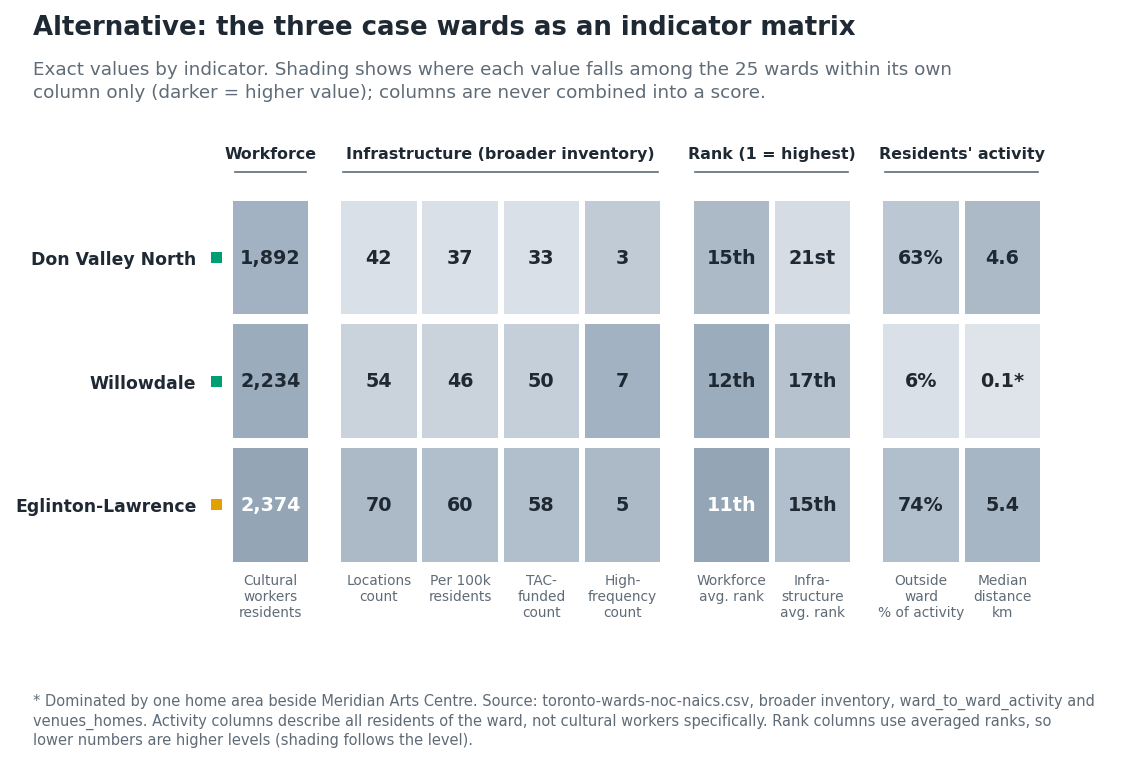

In [19]:
def plot_indicator_matrix(prof, view):
    wards = MAIN_CASE_WARDS
    cw_, rh = 0.83, 0.82
    fig = plt.figure(figsize=(FIG_W, 5.0))
    top = title_block(fig, "Alternative: the three case wards as an indicator matrix",
                      "Exact values by indicator. Shading shows where each value falls among the 25 wards within its own column only (darker = higher value); "
                      "columns are never combined into a score.")
    fig.subplots_adjust(left=0.19, right=0.985, top=top - 0.10, bottom=0.25)
    ax = fig.add_subplot(111)
    xpos, x = [], 0.0
    spans = []
    for gname, cols in MATRIX_GROUPS:
        start = x
        for c in cols:
            xpos.append(x)
            x += cw_
        spans.append((gname, start, x - cw_))
        x += 0.28
    total_w = x - 0.28 + cw_ / 2
    ax.set_xlim(-cw_ / 2, total_w)
    ax.set_ylim(-0.5, len(wards) - 0.5 + 0.0)
    ax.invert_yaxis()
    flat = [c for _, cols in MATRIX_GROUPS for c in cols]
    for ri, w in enumerate(wards):
        for ci, (hdr, unit, key, col, fmt) in enumerate(flat):
            series = view[col]
            val = prof[w][key]
            pct_rank = (series < val).mean() if col not in ("avg_workforce_rank", "avg_infra_rank") else (series > val).mean()     # higher level = darker
            shade = SEQ_CMAP(0.1 + 0.8 * pct_rank)
            ax.add_patch(Rectangle((xpos[ci] - cw_ / 2 + 0.03, ri - 0.5 + 0.04), cw_ - 0.06, 0.92, facecolor=shade, edgecolor="none", zorder=1))
            dark = pct_rank > 0.55
            ax.text(xpos[ci], ri, format_value(fmt, val) + ("*" if (w == "Willowdale" and key == "median_km") else ""), ha="center", va="center", fontsize=9.2, fontweight="bold", color="white" if dark else INK, zorder=3)
    for gname, a, b in spans:
        ax.text((a + b) / 2, -0.78, gname, ha="center", va="bottom", fontsize=7.6, fontweight="bold", clip_on=False)
        ax.plot([a - cw_ / 2 + 0.05, b + cw_ / 2 - 0.05], [-0.69, -0.69], color=MUTED, linewidth=0.8, clip_on=False)
    for ci, (hdr, unit, key, col, fmt) in enumerate(flat):
        ax.text(xpos[ci], -0.6, "", ha="center")
        ax.text(xpos[ci], len(wards) - 0.44, f"{hdr}\n{unit}", ha="center", va="top", fontsize=6.6, color=MUTED, linespacing=1.15, clip_on=False)
    ax.set_yticks(range(len(wards)))
    ax.set_yticklabels(wards)
    for lab in ax.get_yticklabels():
        lab.set_fontweight("bold")
    ax.set_xticks([])
    ax.tick_params(axis="y", length=0, pad=16)
    region_markers(ax, wards, x=-0.015)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(False)
    source_note(fig, "* Dominated by one home area beside Meridian Arts Centre. Source: toronto-wards-noc-naics.csv, broader inventory, ward_to_ward_activity and venues_homes. "
                     "Activity columns describe all residents of the ward, not cultural workers specifically. Rank columns use averaged ranks, so lower numbers are higher levels (shading follows the level).", wrap=140)
    plt.show()


plot_indicator_matrix(profiles, ward_view)

**What it shows.** The same nine indicators for the three case wards, with exact values and column-wise shading.

**Narrative claim.** Identical to the cards: Don Valley North has the lightest infrastructure columns, Eglinton-Lawrence the largest inventory, and Willowdale an unusual activity profile.

**Limitations.** Shading is relative to the 25 wards and says nothing about adequacy. Rank columns use averaged ranks, so a low number is a high level. Willowdale’s 0.1 km median again reflects one home area beside Meridian Arts Centre.

**Cards vs. matrix.** The **profile cards are the better case-study format**: the per-row scales show where each ward sits in the city and make the three opportunity types visible, and the headline for each ward fits naturally on a card. The matrix is more compact and exact, so it works well as a table in an appendix or a Google Doc, but it cannot show how far a value sits from the rest of the city, and the shading adds little beyond the numbers. Recommend the cards for the story and the matrix as a reference.

## 7. Story 2 visual recommendation summary

| Role | Recommended graphic | Why |
|---|---|---|
| **Strongest opening graphic** | Section 1, sorted bar of cultural-worker counts (with the concentration column) | Councillors can find their ward immediately, the suburban case wards sit visibly alongside downtown wards, and the count-versus-concentration distinction is built in. |
| **Strongest regional-context graphic** | Section 2, paired regional bars with gap column | Four regions, two bars each and one gap number; hatching keeps the two measures distinct without a dual axis and the framing avoids implying downtown has too many venues. |
| **Strongest ward-selection graphic** | Section 4, dot matrix of the 12 comparisons and three methods | Shows that the same wards recur across measures at a glance, so the selection looks robust, not cherry-picked. Pair it with the Section 3 scatter as the explanatory visual. |
| **Strongest case-study format** | Section 5, profile cards | Per-row scales show each ward’s position in the city and the three opportunity types stay distinct. Willowdale’s Meridian caveat has a natural home. |
| **Alternatives to drop** | Section 1 choropleth, Section 3 rank dumbbell | The choropleth adds geography but little else and makes the case wards indistinguishable. The rank dumbbell is abstract and surfaces downtown wards, diluting the focus. The Section 6 matrix is best kept as an appendix table. |